# Code to generate the figures of the manuscript "How do mate-finding Allee effects affect evolutionary rescue" 

The data needed to generate the figures is in the Simulations folder. Instructions to generate the relevant files for a figure are given here in the respective sections. 

In [57]:
import numpy as np 
import pandas as pd 
import multiprocessing as mp 
import matplotlib.pyplot as plt 
import seaborn as sb
import matplotlib.patches as mpatches
from scipy.optimize import fsolve


from functools import partial 


In [58]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 17

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)            # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

cmap = plt.cm.brg

pth = "../Simulations/"

# Fig 2 - Critical Values

This requires excel file `LamdaCritical_CM_MRp-4.xlsx` which can be generated by the python code `LambdaCriticalWt.py` (Bash script to run it on a cluster is `LambdaCriticalWt.sh`). 

In addition, panel (c) also requries the excel file `LamdaCriticalMutant_CM_MRp-4_PS10000.xlsx` which can be generated using the python code `LambdaCriticalMt.py` (Bash script for running it on the cluster is `LambdaCriticalMt.sh`)

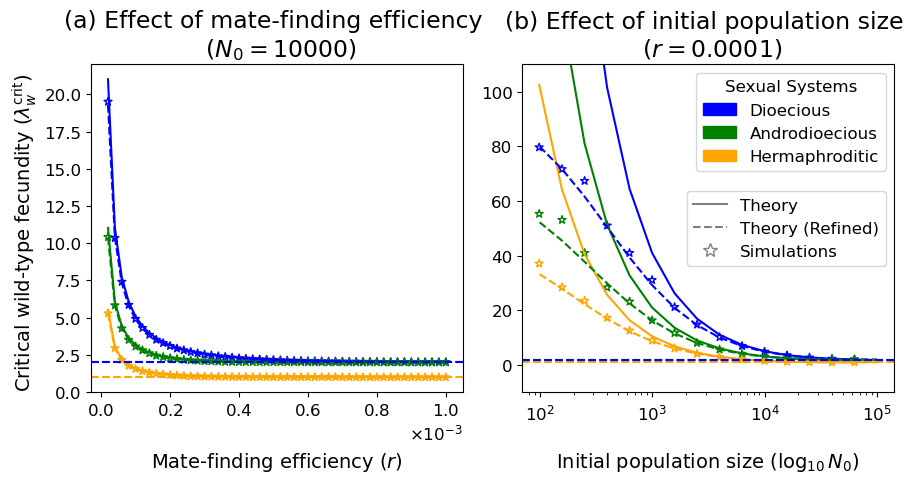

In [59]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

def corrected_crit(r,N0,alpha_f, alpha_m):
    u = 1-np.exp(-r*alpha_m*N0)
       
    return (N0+2)/(alpha_f*u*N0 - 4*(1-u)) * ( 1 - np.sqrt( 1 - (N0**2 - 4*N0*(1-u)/(alpha_f*u))/(N0+2)**2 ) )


writer = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
DF = pd.read_excel(writer, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)
DF = DF[DF.index < 0.00102]
#DF = DF[DF.index >= 0.00006]
colors = ['blue','green','orange']
color_ind =0
fig, ax = plt.subplots(1,2,sharex=False, sharey=False,figsize=(9.2,5))


modelname = ['Dioecious','Androdioecious','Hermaphroditic']
for model_ind, model in enumerate(modelname):
    ax[0].scatter(list(DF.index),list(DF[model]),marker = '*',c='none',edgecolors=colors[color_ind], label = modelname[model_ind]+' - Simulations')
    color_ind += 1
    if model == 'Dioecious':
        analy = [ 2/(1-np.exp(1)**(-r*5000) ) for r in list(DF.index)]
        ax[0].plot(list(DF.index),analy, color = 'blue', label = modelname[model_ind] + ' - Theory')
    elif model == 'Hermaphroditic' :
        analy = [ 1/(1-np.exp(1)**(-r*10000) ) for r in list(DF.index)]
        ax[0].plot(list(DF.index),analy, color = 'orange', label = modelname[model_ind] + ' - Theory')
    elif model == 'Androdioecious' :
        analy = [ 2/(1-np.exp(1)**(-r*10000) ) for r in list(DF.index)]
        ax[0].plot(list(DF.index),analy, color = 'green', label = modelname[model_ind] + ' - Theory')

%matplotlib inline

N0 = 10**(4)

xrange = list(DF.index)
ycorrected = [ corrected_crit(r,N0,1,1) for r in xrange ]
ax[0].plot(xrange, ycorrected, linestyle = '--', color = 'orange')

ycorrected = [ corrected_crit(r,N0,0.5,0.5) for r in xrange ]
ax[0].plot(xrange, ycorrected, linestyle = '--', color = 'blue')

ycorrected = [ corrected_crit(r,N0,0.5,1) for r in xrange ]
ax[0].plot(xrange, ycorrected, linestyle = '--', color = 'green')


ax[0].axhline(y=1,linestyle = '--',color='orange')
ax[0].axhline(y=2,linestyle = '--',color='green')
ax[0].axhline(y=2,linestyle = '--',color='blue')

ax[0].set_xlabel('\nMate-finding efficiency ($r$)')#,fontsize = 15)
ax[0].set_ylabel('Critical wild-type fecundity ($\lambda_w^{\\text{crit}}$)  ')#, fontsize = 15)
ax[0].set_title('(a) Effect of mate-finding efficiency \n ($N_0 = 10000$)')#, fontsize = 18)
ax[0].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax[0].xaxis.major.formatter._useMathText = True
#ax[0].legend(fontsize=10)

DF = pd.read_excel(writer, sheet_name = 'Lamda_Cutoff_N0' ,index_col=0)
DF = DF.loc[DF.index>90]
color_ind =0
for model_ind, model in enumerate(modelname):
    ax[1].scatter(list(DF.index),list(DF[model]),marker = '*',c='none',edgecolors=colors[color_ind], label = modelname[model_ind]+' - Simulations')
    color_ind += 1
    if model == 'Dioecious':
        analy = [ 2/(1-np.exp(1)**(-0.0001*N0*0.5) ) for N0 in list(DF.index)]
        ax[1].plot(list(DF.index),analy, color = 'blue', label = modelname[model_ind] + ' - Theory')
    elif model == 'Androdioecious' :
        analy = [ 2/(1-np.exp(1)**(-0.0001*(N0-1) ) ) for N0 in list(DF.index)]
        ax[1].plot(list(DF.index),analy, color = 'green', label = modelname[model_ind] + ' - Theory')
    elif model == 'Hermaphroditic' :
        analy = [ 1/(1-np.exp(1)**(-0.0001*(N0-1) ) ) for N0 in list(DF.index)]
        ax[1].plot(list(DF.index),analy, color = 'orange', label = modelname[model_ind] + ' - Theory')


r = 10**(-4)

xrange = [10**x for x in np.arange(2,5.1,0.2)]
ycorrected = [ corrected_crit(r,N0,1,1) for N0 in xrange ]
ax[1].plot(xrange, ycorrected, linestyle = '--', color = 'orange')

ycorrected = [ corrected_crit(r,N0,0.5,0.5) for N0 in xrange ]
ax[1].plot(xrange, ycorrected, linestyle = '--', color = 'blue')

ycorrected = [ corrected_crit(r,N0,0.5,1) for N0 in xrange ]
ax[1].plot(xrange, ycorrected, linestyle = '--', color = 'green')


solid_line = mlines.Line2D([], [], color='grey', linestyle='-', label='Theory ')
dashed_line = mlines.Line2D([], [], color='grey', linestyle='--', label='Theory (Refined)')
empty_star = mlines.Line2D([], [], color='grey', marker='*', linestyle='None', markersize=10,
                           markerfacecolor='none', markeredgecolor='grey', label='Simulations')

legend1 = ax[1].legend(handles=[solid_line, dashed_line, empty_star],
                       title="", loc='center right')


# --- Legend for colors on ax[1] ---
blue_patch = mpatches.Patch(color='blue', label='Dioecious')
red_patch = mpatches.Patch(color='green', label='Androdioecious')
orange_patch = mpatches.Patch(color='orange', label='Hermaphroditic')

legend2 = ax[1].legend(handles=[blue_patch, red_patch, orange_patch],
                       title="Sexual Systems", loc='upper right')

# Add first legend manually (otherwise second legend overwrites it)
ax[1].add_artist(legend1)

        
%matplotlib inline
ax[1].axhline(y=1,linestyle = '--',color='orange')
ax[1].axhline(y=2,linestyle = '--',color='green')
ax[1].set_xscale('log')
ax[1].axhline(y=2,linestyle = '--',color='blue')
ax[1].set_xlabel('\nInitial population size ($\log_{10}N_0$)')#,fontsize = 15)
ax[1].set_title('(b) Effect of initial population size \n ($r = 0.0001$)')#, fontsize = 18)
ax[1].set_xscale('log')
ax[1].set_ylim((-10,110))
#ax[1].legend(fontsize=10)
fig.align_xlabels()
plt.tight_layout()
plt.savefig("LambdaCritical.jpg",format="jpg", dpi=300)

plt.show()

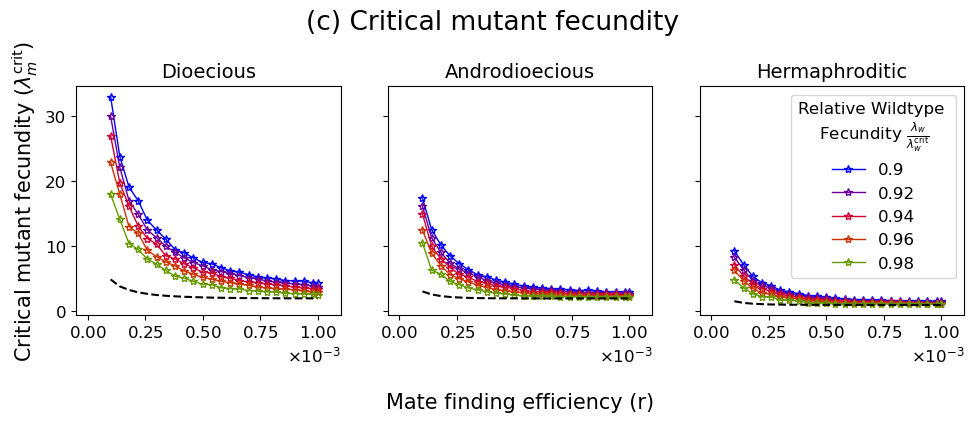

In [60]:
writer = pd.ExcelFile(pth+'LamdaCriticalMutant_CM_MRp-4_PS10000.xlsx')
LCwriter = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
LCDF = pd.read_excel(LCwriter, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)
#lw_crit = [LCDF['Unisexual'][r] for r in r_rng]

fig, ax_pt = plt.subplots(1, 3, sharex=True, sharey=True, figsize = (10,4.3))

DF = pd.read_excel(writer, sheet_name = 'Dioecious',index_col = 0) 


for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])#/np.array([ LCDF['Dioecious'][r] for r in xvals ])
    ax_pt[0].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
    
ax_pt[0].plot(np.array(list(DF.index)), [LCDF['Dioecious'][r] for r in list(DF.index)],  color = 'black', linestyle = '--')
ax_pt[0].set_title('Dioecious',fontsize=14)

DF = pd.read_excel(writer, sheet_name = 'Hermaphroditic',index_col = 0) 
for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])#/np.array([ LCDF['Hermaphroditic'][r] for r in xvals ])
    ax_pt[2].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
ax_pt[2].plot(np.array(list(DF.index)), [LCDF['Hermaphroditic'][r] for r in list(DF.index)], color = 'black', linestyle = '--')
ax_pt[2].set_title('Hermaphroditic',fontsize=14)

DF = pd.read_excel(writer, sheet_name = 'Androdioecious',index_col = 0) 
for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])#/np.array([ LCDF['Androdioecious'][r] for r in xvals ])
    ax_pt[1].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
    
ax_pt[1].plot(np.array(list(DF.index)), [LCDF['Androdioecious'][r] for r in list(DF.index)], color = 'black', linestyle = '--')
lg=ax_pt[2].legend(title = 'Relative Wildtype \n    Fecundity $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}}$')
lg._legend_box.align = "center"
ax_pt[1].set_title('Androdioecious',fontsize=14)

handles, labels = ax_pt[0].get_legend_handles_labels()
ax_pt[0].set_ylabel('Critical mutant fecundity ($\lambda_m^{\\text{crit}}$)', fontsize=15)
ax_pt[1].set_xlabel('\n\nMate finding efficiency (r)', fontsize=15)
ax_pt[0].xaxis.major.formatter._useMathText = True
ax_pt[1].xaxis.major.formatter._useMathText = True
ax_pt[2].xaxis.major.formatter._useMathText = True
plt.xlim(-0.05*10**(-3),1.1*10**(-3))
fig.suptitle('(c) Critical mutant fecundity', fontsize = 19)
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='x', scilimits= (0,0))
plt.savefig("LambdaCriticalMt.jpg",format="jpg", dpi=300)

# Fig 3 - Sexual Systems 

This requires the excel sheet `LamdaCritical_CM_MRp-4.xlsx` (instructions for this are given in Fig 2 description above). In addition, this requires the excel sheets `RescueProb_MatingSystem.xlsx` and `RescueProb_MatingSystem_Norm.xlsx` which can be generated using the same python file `RescueProb_MatingSystem.py`. To generate `RescueProb_MatingSystem_Norm.xlsx`, run the python file as is. To generate `RescueProb_MatingSystem.xlsx` uncoment the commented lines and comments the lines indicated in the file. The bash script to run it on the cluster is ``RescueProb_MatingSystem.sh``

/tmp/ipykernel_234052/1372913560.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


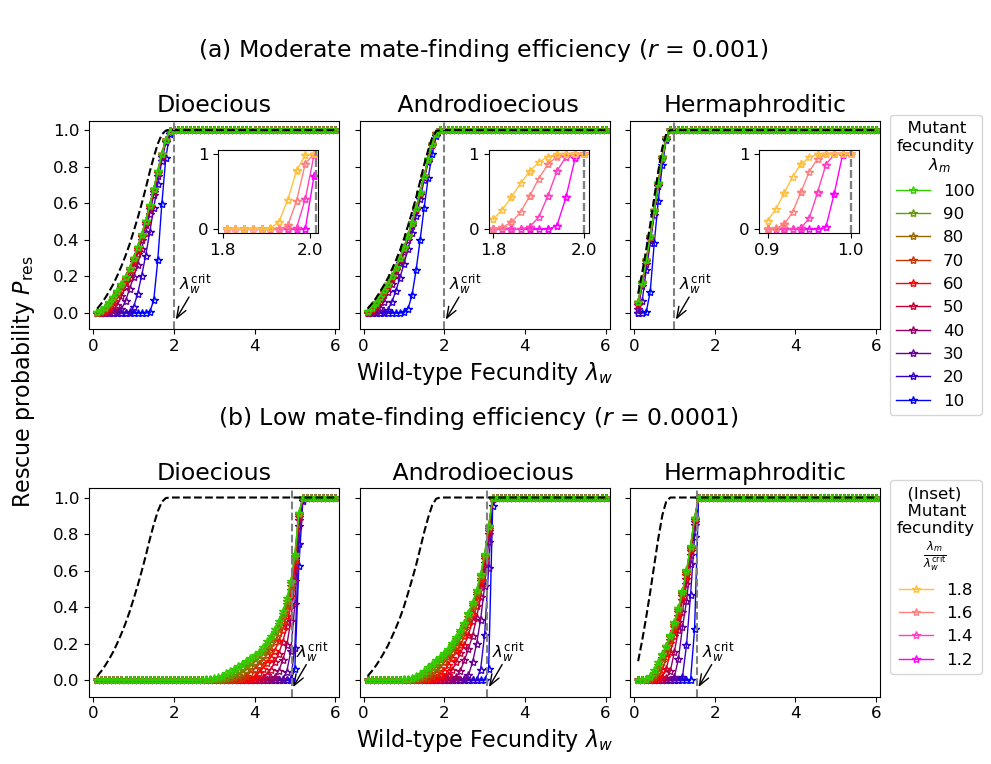

In [61]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


writer = pd.ExcelFile(pth+'RescueProb_MatingSystem.xlsx')
writer_inset = pd.ExcelFile(pth+'RescueProb_MatingSystem_Norm.xlsx')


LCwriter = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
LCDF = pd.read_excel(LCwriter, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)

r_rng = [0.001,0.0001]
r_rng_txt = ['0.001','0.0001']

fig, ax_pt = plt.subplots(2, 3, sharex=True, sharey=True, figsize = (10,7.8))
ty = ['Di','An','He']
modelname = ['Dioecious','Androdioecious','Hermaphroditic']

alpha_fem = [0.5,0.5,1]
alpha_male = [0.5,1,1]
lw_crit = [2.01,2,1]



for i in range(len(ty)) :
    DF_AM = pd.read_excel(writer,sheet_name = str(ty[i])+'_AM', index_col = 0 )
    for j in range(2) :     
        r = r_rng[j]
        DF = pd.read_excel(writer,sheet_name = str(ty[i])+'_'+str(r_rng[j]), index_col = 0 )
        
        for lm_ind, lm in enumerate(DF.columns[1::]):
            col = cmap(lm_ind/len(DF.columns[1::]))
            ax_pt[j][i].plot(DF.index,1-np.array(DF[lm]), color = col, marker = '*', lw=1, mfc ='none',label = str(lm))
        ax_pt[j][i].plot(DF_AM.index,1-np.array(DF_AM[10]), linestyle = '--', color = 'black')
        
        ax_pt[j][i].set_title(modelname[i])
        ax_pt[j][i].axvline(x=LCDF[modelname[i]][r],linestyle ='--',color='grey',label='$\lambda_w^{\\text{crit}}$')
        
        ax_pt[j][i].xaxis.set_tick_params(which='both', labelbottom=True)
        arr = mpatches.FancyArrowPatch((LCDF[modelname[i]][r]+0.4,0.1), (LCDF[modelname[i]][r],-0.05),
                                   arrowstyle='->,head_width=.15', mutation_scale=20)
        ax_pt[j][i].add_patch(arr)
        ax_pt[j][i].annotate('$\lambda_w^{\\text{crit}}$', (1.5, 1), xycoords=arr, ha='center', va='bottom')
        
        
        if j == 0 : 
            axin = inset_axes(ax_pt[j][i], width="40%", height="40%", loc='upper right', bbox_to_anchor=(-0.05,-0.1,1,1), bbox_transform=ax_pt[j][i].transAxes)
            DF = pd.read_excel(writer_inset,sheet_name = str(ty[i])+'_'+str(r_rng[j]), index_col = 0 )
            cmap_inset = plt.cm.spring
            for lm_ind, lm in enumerate([1.2,1.4,1.6,1.8]):
                
                axin.plot(np.array(DF.index)*lw_crit[i],1-np.array(DF[lm]),c=cmap_inset(lm_ind/4),lw=1, mfc = 'none', marker = '*',label = str(lm))
                axin.set_xlim((round(lw_crit[i]*0.90,1)-0.01,lw_crit[i]+0.01 ))
                axin.set_ylim(-0.05,1.05)
                axin.axvline(x=1/(alpha_fem[i]*(1-np.exp(-r*alpha_male[i]*10**4))),linestyle ='--',color='grey')
    
            


ax_pt[1][1].set_title('(b) Low mate-finding efficiency ($r$ = 0.0001) \n\n Androdioecious', x=0.48)#, fontsize = 17)
ax_pt[0][1].set_title('\n(a) Moderate mate-finding efficiency ($r$ = 0.001) \n\n Androdioecious')#, fontsize = 17)
fig.supylabel('Rescue probability $P_{\\text{res}}$', fontsize = 16)
ax_pt[0][1].set_xlabel('Wild-type Fecundity $\lambda_w$', fontsize = 16)
ax_pt[1][1].set_xlabel('Wild-type Fecundity $\lambda_w$', fontsize = 16)
plt.tight_layout()
ax_pt[0][0].set_xlim(-0.1,6.1)
handles, labels = ax_pt[0][2].get_legend_handles_labels()
fig.legend(handles[::-1][1:], labels[::-1][1:], loc='right',bbox_to_anchor=(1,0.65),title = '  Mutant \nfecundity\n      $\lambda_m$')      

handles, labels = axin.get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1,0.25),title = '  (Inset) \n  Mutant \nfecundity\n     $\\frac{\lambda_m}{\lambda_w^{\\text{crit}}}$')      

plt.subplots_adjust(right=0.89)
plt.savefig("RescueProb_MatingSystem.jpg",format="jpg", dpi=300)



# Fig 4 - SGV vs DNM

This requires the excel file `RescueProb_SGVvsDNM.xlsx` which can be generated using the python code `RescueProb_SGVvsDNM.py` (The bash script to run it on the cluseter is `RescueProb_SGVvsDNM.sh`)

/tmp/ipykernel_234052/3541149883.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


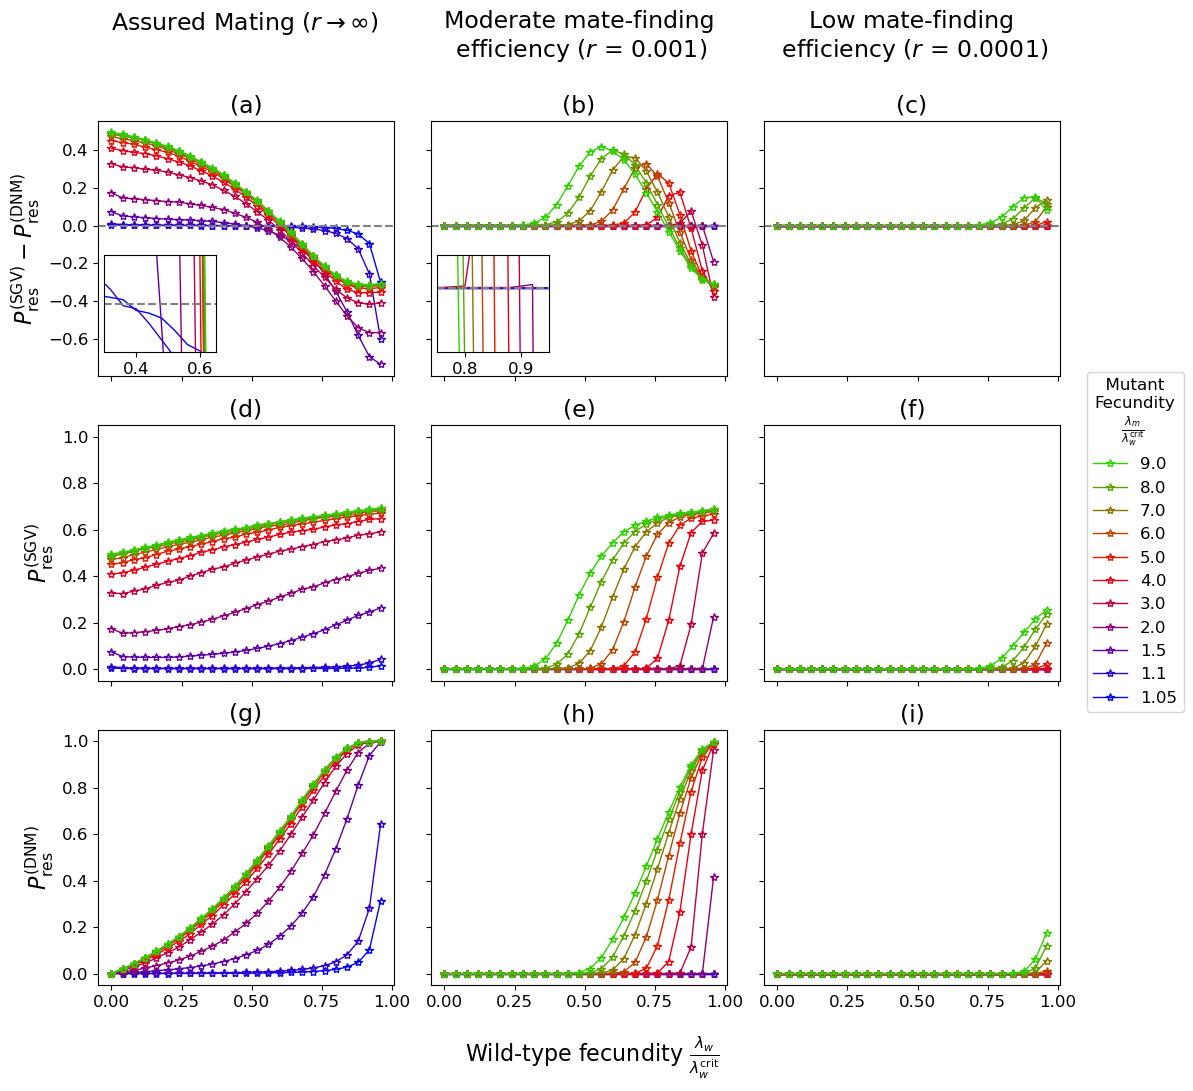

In [62]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
writer = pd.ExcelFile(pth+'RescueProb_SGVvsDNM.xlsx')

r_rng = ['AM',0.001,0.0001]
r_rng_txt = ['0.001','0.0001','AM']

fig, ax_pt = plt.subplots(3, 3, sharex=True, sharey='row', figsize = (12,11))
ty = ['SGV','DNM']
modelname = ['SGV','denovo mutation']


for j in range(3) :     
    r = r_rng[j]
    DF_SGV = pd.read_excel(writer,sheet_name = str(ty[0])+'_'+str(r_rng[j]), index_col = 0 )
    DF_DNM = pd.read_excel(writer,sheet_name = str(ty[1])+'_'+str(r_rng[j]), index_col = 0 )        
    for lw_ind, lw in enumerate(DF_DNM.columns):
        
        x_list = [x for x in DF_DNM.index if x < 1]
        y_list = np.array(DF_DNM[lw])-np.array(DF_SGV[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[0][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
        x_list = [x for x in DF_DNM.index if x < 1]
        y_list = 1-np.array(DF_SGV[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[1][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
        y_list = 1-np.array(DF_DNM[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[2][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
    ax_pt[0][j].axhline(y=0,linestyle = '--',color='grey')
    
    if j != 2 :
        axin = inset_axes(ax_pt[0][j], width="38%", height="38%", loc='lower center', bbox_to_anchor=(-0.29,0.06,1,1), bbox_transform=ax_pt[0][j].transAxes)
        for lw_ind, lw in enumerate(DF_DNM.columns):
            x_list = [x for x in DF_DNM.index if x < 1]
            y_list = np.array(DF_DNM[lw])-np.array(DF_SGV[lw])
            y_list = y_list[0:len(x_list)]
            axin.plot(np.array(x_list),y_list, color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
            #axin.set_xticks([])
            axin.set_yticks([])
            if j == 0:
                axin.set_xlim(0.3,0.65)
                axin.set_ylim(-0.0025,0.0025)
            elif j == 1:
                axin.set_xlim(0.75,0.95)
                axin.set_ylim(-0.005,0.0025)
        axin.axhline(y=0,linestyle = '--',color='grey')
        

ax_pt[0][2].set_title('Low mate-finding\n efficiency ($r$ = 0.0001) \n\n(c)')
ax_pt[0][1].set_title('Moderate mate-finding\n efficiency ($r$ = 0.001) \n\n(b)')
ax_pt[0][0].set_title('Assured Mating ($r \\rightarrow \\infty$) \n \n\n(a)')

ax_pt[1][2].set_title('(f)')
ax_pt[1][1].set_title('(e)')
ax_pt[1][0].set_title('(d)')

ax_pt[2][2].set_title('(i)')
ax_pt[2][1].set_title('(h)')
ax_pt[2][0].set_title('(g)')


handles, labels = ax_pt[0][0].get_legend_handles_labels()
handles2, labels2 = ax_pt[0][2].get_legend_handles_labels()
fig.legend(handles2[::-1], labels2[::-1], loc='right',bbox_to_anchor=(1,0.5),title = '  Mutant \nFecundity\n     $\\frac{\lambda_m}{\lambda_w^{\\text{crit}}}$')
fig.supxlabel('Wild-type fecundity $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}}$', fontsize = 16)
ax_pt[0][0].set_ylabel('$P_{\\text{res}}^{(\\text{SGV})}-P_{\\text{res}}^{(\\text{DNM})}$', fontsize = 16)
        
ax_pt[1][0].set_ylabel('$P_{\\text{res}}^{(\\text{SGV})}$', fontsize = 16)
ax_pt[2][0].set_ylabel('$P_{\\text{res}}^{(\\text{DNM})}$', fontsize = 16)

ax_pt[1][0].set_ylim(-0.05,1.05)
ax_pt[2][0].set_ylim(-0.05,1.05)

plt.tight_layout()
plt.subplots_adjust(right=0.89)
plt.savefig("RescueProb_SGVvsDNM.jpg",format="jpg", dpi=300)

# Fig 5 - Finding vs Fecundity 

This requires the excel file `RescueProb_FindingvsFecundity.xlsx` which can be generated using the python code `RescueProb_FindingvsFecundity.py` (The bash script to run it on the cluseter is `RescueProb_FindingvsFecundity.sh`)

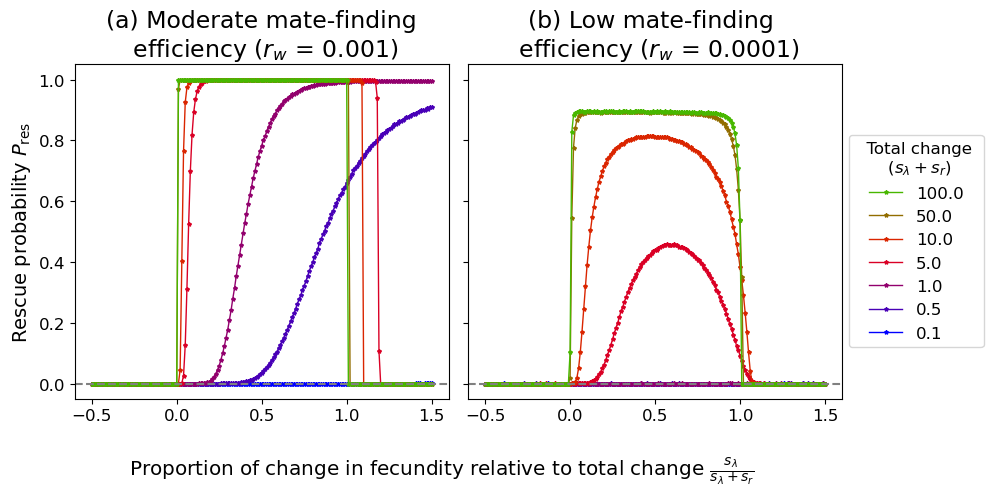

In [63]:
for typ in [""]:
    writer = pd.ExcelFile(pth+'RescueProb_FindingvsFecundity' + typ + '.xlsx')

    r_rng = [0.001, 0.0001]
    r_rng_txt = ['0.001', '0.0001']

    %matplotlib inline
    fig, ax_pt = plt.subplots(1, 2, sharey=True, sharex=True, figsize = (10,5))

    for i in range(len(r_rng)) :
        r = r_rng[i]
        DF = pd.read_excel(writer,sheet_name = str(r_rng[i]), index_col = 0 )
        DF = DF.transpose()
        for lw_ind, lw in enumerate(DF.columns):
            ax_pt[i].plot(DF.index,1-np.array(DF[lw]),color = cmap(lw_ind/len(DF.columns)),mfc ='none',lw=1, marker = '*',label = str(lw/100),ms=3)
        ax_pt[i].tick_params(axis='both')#, labelsize=13)
        ax_pt[i].axhline(y=0, linestyle = '--', color = 'grey')

    ax_pt[1].set_title("(b) Low mate-finding \n efficiency ($r_w$ = 0.0001)")#, fontsize = 13)
    ax_pt[0].set_title("(a) Moderate mate-finding\n efficiency ($r_w$ = 0.001)")#, fontsize = 13)

    ax_pt[0].set_ylabel('Rescue probability $P_{\\text{res}}$')#, fontsize = 19)
    #fig.supxlabel('Proportion of increase allocated to Fecundity $\\frac{\lambda_w^{-1}\Delta \lambda}{\lambda_w^{-1}\Delta \lambda + r_w^{-1}\Delta r}$', fontsize = 19,x=0.45)
    fig.supxlabel('Proportion of change in fecundity relative to total change $\\frac{s_\lambda}{s_\lambda+s_r}$',x=0.45)
    plt.tight_layout()
    handles, labels = ax_pt[0].get_legend_handles_labels()
    fig.legend(handles[::-1], np.array(labels[::-1]), loc='right',bbox_to_anchor=(1,0.5),title = '  Total change \n      $(s_\lambda+s_r)$ ')      
    plt.subplots_adjust(right=0.85)
    plt.savefig('RescueProb_FindingvsFecundity'+ typ + ".jpg",format="jpg", dpi=300)
    plt.show()

# Fig 6 - Sex Ratio  

This requires the excel file `RescueProb_SexRatio.xlsx` which can be generated using the python code `RescueProb_SexRatio.py` (The bash script to run it on the cluseter is `RescueProb_SexRatio.sh`)

/tmp/ipykernel_234052/166192970.py:7: RuntimeWarning: divide by zero encountered in double_scalars
  return 1/(alpha*(1-np.exp(-r*(1-alpha)*N0)))
/tmp/ipykernel_234052/166192970.py:7: RuntimeWarning: divide by zero encountered in double_scalars
  return 1/(alpha*(1-np.exp(-r*(1-alpha)*N0)))


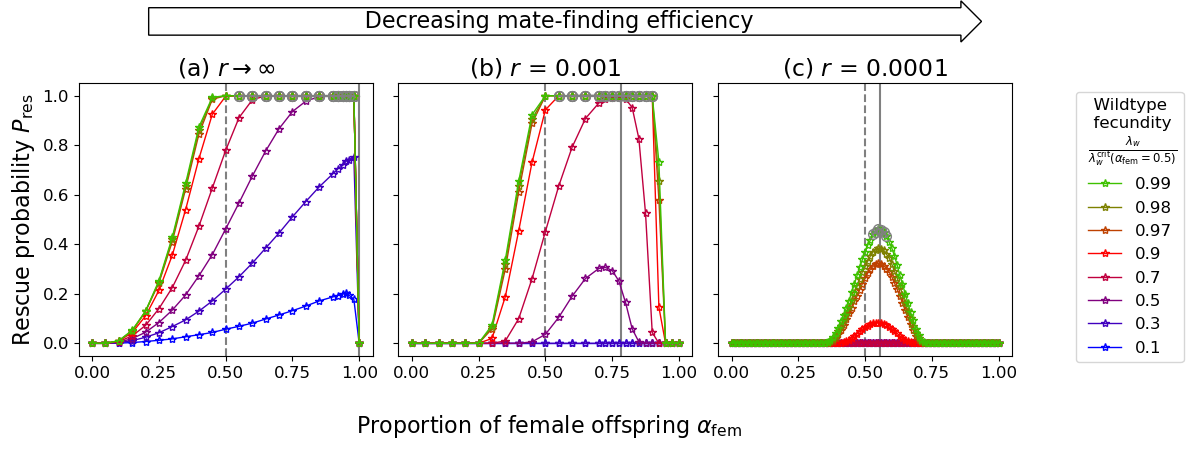

/tmp/ipykernel_234052/166192970.py:66: RuntimeWarning: divide by zero encountered in double_scalars
  return 1/(alpha*(1-np.exp(-r*N0)))
/tmp/ipykernel_234052/166192970.py:66: RuntimeWarning: divide by zero encountered in double_scalars
  return 1/(alpha*(1-np.exp(-r*N0)))


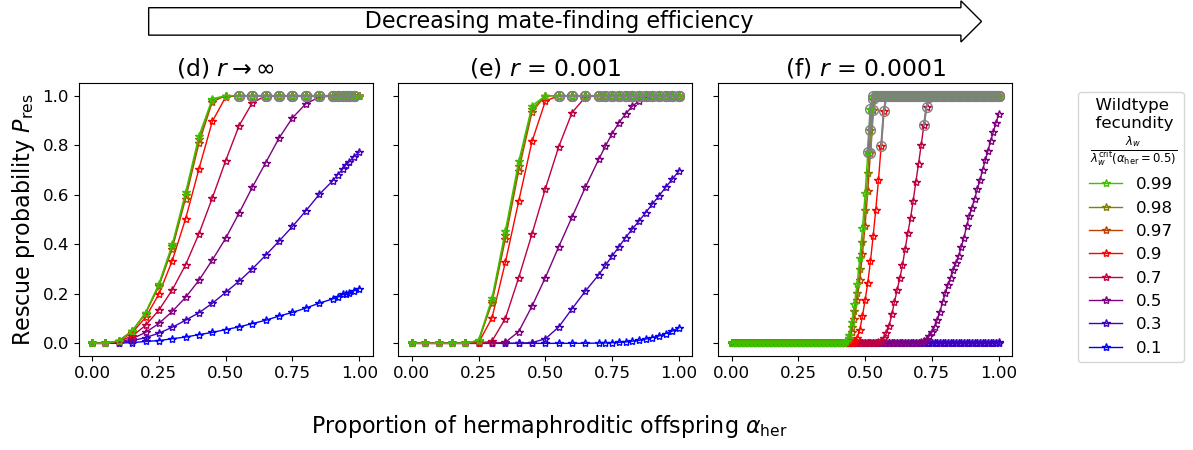

In [64]:
writer = pd.ExcelFile(pth+'RescueProb_SexRatio.xlsx')
#writerAM = pd.ExcelFile('RescueProb_SexRatio_AssuredMating_30.xlsx')
from scipy.optimize import minimize

def lwcrit(r,alpha):
    if r != 'AM':
        return 1/(alpha*(1-np.exp(-r*(1-alpha)*N0)))
    else:
        return 1/alpha if alpha !=0 and alpha !=1 else 10**5


r_rng = [0.0001,0.001,'AM'][::-1]
model = 'Dioecious'
letter = ['(a)', '(b)','(c)']
fig, ax = plt.subplots(1,3,figsize = (12,4.2),sharex=True,sharey=True)

for r_ind,r in enumerate(r_rng): 
    DF = pd.read_excel(writer,sheet_name = model+'_'+str(r), index_col = 0 )
    DF = DF.transpose()
    N0 = 10**4
    if r!= 'AM':
        def sex_ratio(alpha):
            return 1/(alpha*( 1-np.exp(-r*(1-alpha)*N0)))
        alpha_solution = minimize(sex_ratio,0.8)
        alpha_solution = alpha_solution.x[0]
    else :
        alpha_solution = 1 - 10**(-3)
        
    ax[r_ind].axvline(x=alpha_solution, linestyle = 'solid', color = 'grey')
    ax[r_ind].axvline(x=0.5, linestyle = '--', color = 'grey')

    for s_ind, s in enumerate(DF.columns): 
        ax[r_ind].plot(list(DF.index),1-np.array(DF[s]), color = cmap(s_ind/len(DF.columns)), mfc='none',lw=1, label = str(round(s,2)), marker ='*' )
        ax[r_ind].set_title(letter[r_ind]+' $r$ = '+str(r)) if r != 'AM' else ax[r_ind].set_title(letter[r_ind]+' $r \\rightarrow \infty$')#,fontsize = 13) 
        
        DFindex_supercrit = [] 
        DFs_supercrit = [] 
        
        for DFindex_ind, DFindex in enumerate(DF.index):
            if s*lwcrit(r,0.5) > lwcrit(r,DFindex):
                DFindex_supercrit += [ DFindex ]
                DFs_supercrit += [1 - DF[s][DFindex] ]
        ax[r_ind].plot(DFindex_supercrit,DFs_supercrit,marker = 'o',mfc = 'none',markersize =7,mec = 'grey', color = 'grey')
        
ax[0].set_ylabel('Rescue probability $P_{\\text{res}}$',fontsize = 16)
ax[1].set_xlabel('\n Proportion of female offspring $\\alpha_{\\text{fem}}$', fontsize = 16)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1,0.55),title = '  Wildtype\n  fecundity\n $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}(\\alpha_\\text{fem}=0.5)}$')      
ax = ax[0]
plt.tight_layout()
bbox_props = dict(boxstyle="rarrow, pad=0.1", fc="none", ec="black", lw=1)
t = ax.text(0.22,1.3,30*' '+'Decreasing mate-finding efficiency'+30*' ', ha="left", va="center",size=16,bbox=bbox_props)
plt.subplots_adjust(right=0.85)

plt.savefig("RescueProb_SexRatio_Dio.jpg",format="jpg", dpi=300,bbox_inches='tight')

plt.show()

model = 'Androdioecious'
letter = ['(d)', '(e)','(f)']
fig, ax = plt.subplots(1,3,figsize = (12,4.2),sharex=True,sharey=True)


def lwcrit(r,alpha):
    if r != 'AM':
        return 1/(alpha*(1-np.exp(-r*N0)))
    else:
        return 1/alpha if alpha !=0 and alpha !=1 else 10**5
    
for r_ind,r in enumerate(r_rng): 
    DF = pd.read_excel(writer,sheet_name = model+'_'+str(r), index_col = 0 )
    DF = DF.transpose()
    for s_ind, s in enumerate(DF.columns): 
        ax[r_ind].plot(list(DF.index),1-np.array(DF[s]), color = cmap(s_ind/len(DF.columns)), mfc='none',lw=1, label = str(round(s,2)), marker ='*' )
        ax[r_ind].set_title(letter[r_ind]+' $r$ = '+str(r)) if r != 'AM' else ax[r_ind].set_title(letter[r_ind]+' $r \\rightarrow \infty$')
        
        DFindex_supercrit = [] 
        DFs_supercrit = [] 
        
        for DFindex_ind, DFindex in enumerate(DF.index):
            if s*lwcrit(r,0.5) > lwcrit(r,DFindex):
                DFindex_supercrit += [ DFindex ]
                DFs_supercrit += [1 - DF[s][DFindex] ]
        ax[r_ind].plot(DFindex_supercrit,DFs_supercrit,marker = 'o',mfc = 'none',markersize =7,mec = 'grey', color = 'grey')
        
        
ax[0].set_ylabel('Rescue probability $P_{\\text{res}}$', fontsize=16)
ax[1].set_xlabel('\n Proportion of hermaphroditic offspring $\\alpha_{\\text{her}}$', fontsize = 16)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1,0.55),title = '  Wildtype\n  fecundity\n $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}(\\alpha_\\text{her}=0.5)}$')      
plt.tight_layout()
plt.subplots_adjust(right=0.85)
ax = ax[0]
bbox_props = dict(boxstyle="rarrow, pad=0.1", fc="none", ec="black", lw=1)
t = ax.text(0.22,1.3,30*' '+'Decreasing mate-finding efficiency'+30*' ', ha="left", va="center",
            size=16,bbox=bbox_props)
plt.savefig("RescueProb_SexRatio_And.jpg",format="jpg", dpi=300,bbox_inches='tight')

# Fig 7 - Selfing

This requires the excel file `RescueProb_Selfing.xlsx` which can be generated using the python code `RescueProb_Selfing.py` (The bash script to run it on the cluseter is `RescueProb_Selfing.sh`)

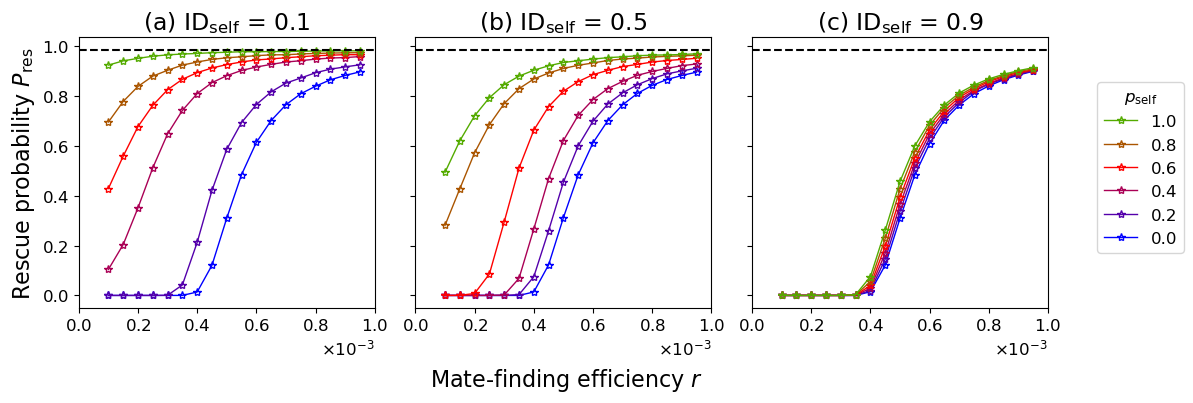

In [65]:
writer = pd.ExcelFile(pth+'RescueProb_Selfing.xlsx')
r_rng = [0.1,0.5,0.9]
model = 'Androdioecious'
letter = ['(a)', '(b)','(c)']
fig, ax = plt.subplots(1,3,figsize = (12,4.2),sharex=True,sharey=True)

for r_ind,r in enumerate(r_rng): 
    DF = pd.read_excel(writer,sheet_name = model+'_'+str(r), index_col = 0 )
    DF = DF.transpose()
    #print(DF)
    for pself_ind, pself in enumerate(DF.columns): 
        ax[r_ind].plot(list(DF.index),1-np.array(DF[pself]), label = str(round(pself,8)), color=cmap(pself_ind/len(DF.columns)), lw =1, mfc='none', marker ='*' )
        ax[r_ind].set_title(letter[r_ind]+' $\\text{ID}_{\\text{self}}$ = '+str(r))
    #ax[r_ind].set_xticks(ticks = ax[r_ind].get_xticks(),labels = ax[r_ind].get_xticklabels() ,fontsize=20)
    ax[r_ind].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
    ax[r_ind].xaxis.major.formatter._useMathText = True
    ax[r_ind].axhline(y=1-0.01274, linestyle = '--', color ='black')
    
    

plt.xlim((0,0.001))

ax[0].set_ylabel('Rescue probability $P_{\\text{res}}$',fontsize = 16)
ax[1].set_xlabel('\n Mate-finding efficiency $r$', fontsize = 16)
handles, labels = ax[0].get_legend_handles_labels()
leg = fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1,0.58),title = '$p_{\\text{self}}$')      
plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig("RescueProb_Selfing.jpg",format="jpg", dpi=300,bbox_inches='tight')

# Supplemental Figures 

## Fig S2 and S3 - Decay rates of scaled and unscaled wild-type fecundities

This only require `LamdaCritical_CM_MRp-4.xlsx`. See Figure 2 instructions for generating the file

In [66]:
def Unisexual(r,lw,lm,N0=10**4,mu=10**(-4),sgv=0,sr=0.5, timeseries=False) :
    """
    Simulates the eco-evolutionary dynamics of a population of unisexuals (dioecious) until either the population goes
    extinct or reaches twice the starting population size N0.
    
    Parameters
    ----------
    r : float (positive)
        The mate-searching efficiency
    lw : float (positive)
        The fecundity of the wildtype, i.e. the mean number of offsprings produced conditional on finding a mate.  
    lm : float (positive)
        The fecundity of the mutant, i.e. the mean number of offsprings produced conditional on finding a mate.  
    N0 : int
        The starting total population size. 
    sgv : float (between 0 and 1)
        The percentage of the starting population size that is mutant. 
    sr : float (between 0 and 1)
        The proportion of offsprings that are female. 
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    
    np.random.seed()
    #mu = 0.0001
    Xm = round(sgv*N0)
    Xw = N0 - Xm 
    #NoG = 1000
    T = 0 #Time to first Mutation
    DidMutationOccur = False
    lamda_w = lw
    lamda_m = lm
    [Xw_M,Xw_F] = np.random.multinomial(Xw,[1-sr,sr])
    [Xm_M,Xm_F] = np.random.multinomial(Xm,[1-sr,sr])
    Ext = 0 
    if timeseries: 
        Xseries = [ [Xw,Xm] ]
    else:
        Xseries = [] 
    while True : 
        if Xm_M + Xm_F == 0 and DidMutationOccur == False : 
            T += 1
        if Xm_M + Xm_F > 0 : 
            DidMutationOccur = True
        X_M = Xm_M + Xw_M
        X_F = Xm_F + Xw_F
        if X_M == 0 or X_F == 0 : 
            Ext = 1 
            if DidMutationOccur == False:
                T = np.inf
            break
        elif X_M + X_F > 2*N0 : 
            break 
        
        if r == 'AM':
            Xm_Mate = Xm_F
            Xw_Mate = Xw_F
        else: 
            Xm_Mate = np.random.binomial(Xm_F, 1 - np.exp(-r*X_M)) 
            Xw_Mate = np.random.binomial(Xw_F, 1 - np.exp(-r*X_M)) 
        
        [Xww,Xwm] = np.random.multinomial(Xw_Mate, [Xw_M/X_M,Xm_M/X_M])
        [Xmw,Xmm] = np.random.multinomial(Xm_Mate, [Xw_M/X_M,Xm_M/X_M])
        
        lamda_w_eff = (Xww + 0.5*Xwm)*lamda_w + 0.5*Xmw*lamda_m 
        lamda_m_eff = (Xmm + 0.5*Xmw)*lamda_m + 0.5*Xwm*lamda_w 
        
        Xw = np.random.poisson((1-mu)*lamda_w_eff)
        Xm = np.random.poisson(lamda_m_eff+mu*lamda_w_eff)
        [Xw_M,Xw_F] = np.random.multinomial(Xw,[1-sr,sr])
        [Xm_M,Xm_F] = np.random.multinomial(Xm,[1-sr,sr])
        
        if timeseries: 
            Xseries = Xseries + [ [Xw_F + Xw_M, Xm_F + Xm_M] ]
    return [Ext,Xseries,T]
        
def Bisexual(r,lw,lm,N0=10**4,mu=10**(-4),sgv=0, ID_self=0, ps=0, timeseries=False):
    """
    Simulates the eco-evolutionary dynamics of a population of bisexual (hermaphrodites) until either the population goes
    extinct or reaches twice the starting population size.
    
    Parameters
    ----------
    r : float (positive)
        The mate-searching efficiency
    lw : float (positive)
        The fecundity of the wildtype, i.e. the mean number of offsprings produced conditional on finding a mate.  
    lm : float (positive)
        The fecundity of the mutant, i.e. the mean number of offsprings produced conditional on finding a mate.  
    N0 : int
        The starting total population size. 
    sgv : float (between 0 and 1)
        The percentage of the starting population size that is mutant. 
    sr : float (between 0 and 1)
        The proportion of offsprings that are hermaphrodites. 
    ps : float (between 0 and 1)
        The probability of selfing. 
    ID_self : float (between 0 and 1)
        The coefficient of inbreeding depression, i.e., the fecundity of a selfed individual is reduced by a factor of 1-ID_self
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    
    np.random.seed()
    #mu = 0.0001
    Xm = round(sgv*N0)
    Xw = N0-Xm
    #NoG = 1000
    T = 0 #Time to first Mutation
    DidMutationOccur = False
#    lamda_w = lamda
#    lamda_m = lamda
    Ext = 0 
    if timeseries : 
        Xseries = [ [Xw,Xm] ]
    else:
        Xseries = []
#    ps = 0
#    ID_self = 0
    while True :
        if Xm == 0 and DidMutationOccur == False: 
            T += 1
        if Xm > 0 : 
            DidMutationOccur = True
        X = Xm + Xw
        if X == 0 : 
            Ext = 1 
            if DidMutationOccur == False : 
                T = 0
            break
        elif X > 2*N0 : 
            break 
            
        if r == 'AM':
            [Xw_Mate,Xw_Self,Xw_NoMate] = [Xw,0,0]
            [Xm_Mate,Xm_Self,Xm_NoMate] = [Xm,0,0]
            
        else:
            [Xw_Mate,Xw_Self,Xw_NoMate] = np.random.multinomial(Xw, [1 - np.exp(-r*(X-1) ), ps*np.exp(-r*(X-1)), (1-ps)*np.exp(-r*(X-1))  ])
            [Xm_Mate,Xm_Self,Xm_NoMate] = np.random.multinomial(Xm, [1 - np.exp(-r*(X-1) ), ps*np.exp(-r*(X-1)), (1-ps)*np.exp(-r*(X-1))  ])
            
        Xww = 0 
        Xwm = 0
        Xmw = 0
        Xmm = 0 
        
        if X - 1 > 0 : 
            if Xw_Mate > 0 :
                [Xww,Xwm] = np.random.multinomial(Xw_Mate, [(Xw - 1)/(X-1),Xm/(X-1)])
            if Xm_Mate > 0 :
                [Xmw,Xmm] = np.random.multinomial(Xm_Mate, [Xw/(X-1),(Xm - 1)/(X-1)])
        
        lamda_w_eff = (Xww + 0.5*Xwm)*lw + 0.5*Xmw*lm + Xw_Self*(1 - ID_self)*lw
        lamda_m_eff = (Xmm + 0.5*Xmw)*lm + 0.5*Xwm*lw + Xm_Self*(1 - ID_self)*lm
        
        Xw = np.random.poisson((1-mu)*lamda_w_eff)
        Xm = np.random.poisson(lamda_m_eff + mu*lamda_w_eff)
        if timeseries: 
            Xseries = Xseries + [ [Xw, Xm] ]
    return [Ext,Xseries,T]

def Androdioecious(r,lw,lm,N0=10**4,mu=10**(-4),sgv=0,sr=0.5,ps=0,ID_self=0,timeseries=False) :
    """
    Simulates the eco-evolutionary dynamics of a population of androdioecious individuals until either the population goes
    extinct or reaches twice the starting population size.
    
    Parameters
    ----------
    r : float (positive)
        The mate-searching efficiency
    lw : float (positive)
        The fecundity of the wildtype, i.e. the mean number of offsprings produced conditional on finding a mate.  
    lm : float (positive)
        The fecundity of the mutant, i.e. the mean number of offsprings produced conditional on finding a mate.  
    N0 : int
        The starting total population size. 
    sgv : float (between 0 and 1)
        The percentage of the starting population size that is mutant. 
    sr : float (between 0 and 1)
        The proportion of offsprings that are hermaphrodites. 
    ps : float (between 0 and 1)
        The probability of selfing. 
    ID_self : float (between 0 and 1)
        The coefficient of inbreeding depression, i.e., the fecundity of a selfed individual is reduced by a factor of 1-ID_self
        
    Returns
    -------
    Ext : int (0 or 1)
        Is 0 is the population survives and 1 if the population went extinct
    Xseries : list of lists
        The timeseries data of Xm and Xw. 
    T : int (postive)
        The time to first mutation in generations. 
    """
    
    np.random.seed()
    #mu = 0.0001
    Xm = round(sgv*N0)
    Xw = N0 - Xm
    #NoG = 1000
    T = 0 #Time to first Mutation
    DidMutationOccur = False
#    lamda_w = lamda
#    lamda_m = lamda
    [Xw_M,Xw_B] = np.random.multinomial(Xw,[1-sr,sr])
    [Xm_M,Xm_B] = np.random.multinomial(Xm,[1-sr,sr])
    Ext = 0
#    ps = 0 
    ID_self = 0 
    if timeseries:
        N = [ [Xw,Xm] ]
    else:
        N = []
    while True : 
        X_M = Xm_M + Xw_M
        X_B = Xm_B + Xw_B
        Xw = Xw_M + Xw_B
        Xm = Xm_M + Xm_B
        if Xm == 0 and DidMutationOccur == False: 
            T += 1
        if Xm > 0 : 
            DidMutationOccur = True
        X = X_M + X_B
        if X == 0 : 
            Ext = 1
            if DidMutationOccur == False : 
                T = np.inf
            break
        if X_M + X_B > 2*N0 : 
            break 
        if r == 'AM':
            [Xw_Mate,Xw_Self,Xw_NoMate] = [Xw_B,0,0]
            [Xm_Mate,Xm_Self,Xm_NoMate] = [Xm_B,0,0]
        else:
            [Xw_Mate,Xw_Self,Xw_NoMate] = np.random.multinomial(Xw_B, [1 - np.exp(-r*(X-1) ), ps*np.exp(-r*(X-1)), (1-ps)*np.exp(-r*(X-1))  ])
            [Xm_Mate,Xm_Self,Xm_NoMate] = np.random.multinomial(Xm_B, [1 - np.exp(-r*(X-1) ), ps*np.exp(-r*(X-1)), (1-ps)*np.exp(-r*(X-1))  ])
        
        Xww = 0 
        Xwm = 0
        Xmw = 0
        Xmm = 0
        
        if X - 1 > 0 : 
            if Xw_Mate > 0 :
                [Xww,Xwm] = np.random.multinomial(Xw_Mate, [(Xw - 1)/(X-1),Xm/(X-1)])
            if Xm_Mate > 0 :
                [Xmw,Xmm] = np.random.multinomial(Xm_Mate, [Xw/(X-1),(Xm - 1)/(X-1)])
        
        lamda_w_eff = (Xww + 0.5*Xwm)*lw + 0.5*Xmw*lm + Xw_Self*(1 - ID_self)*lw
        lamda_m_eff = (Xmm + 0.5*Xmw)*lm + 0.5*Xwm*lw + Xm_Self*(1 - ID_self)*lm
        
        Xw = np.random.poisson((1-mu)*lamda_w_eff)
        Xm = np.random.poisson(lamda_m_eff+ mu*lamda_w_eff)
        [Xw_M,Xw_B] = np.random.multinomial(Xw,[1-sr,sr])
        [Xm_M,Xm_B] = np.random.multinomial(Xm,[1-sr,sr])
        
        if timeseries: 
            N = N + [ [Xw_B + Xw_M, Xm_B + Xm_M] ]
    return [Ext,N,T]

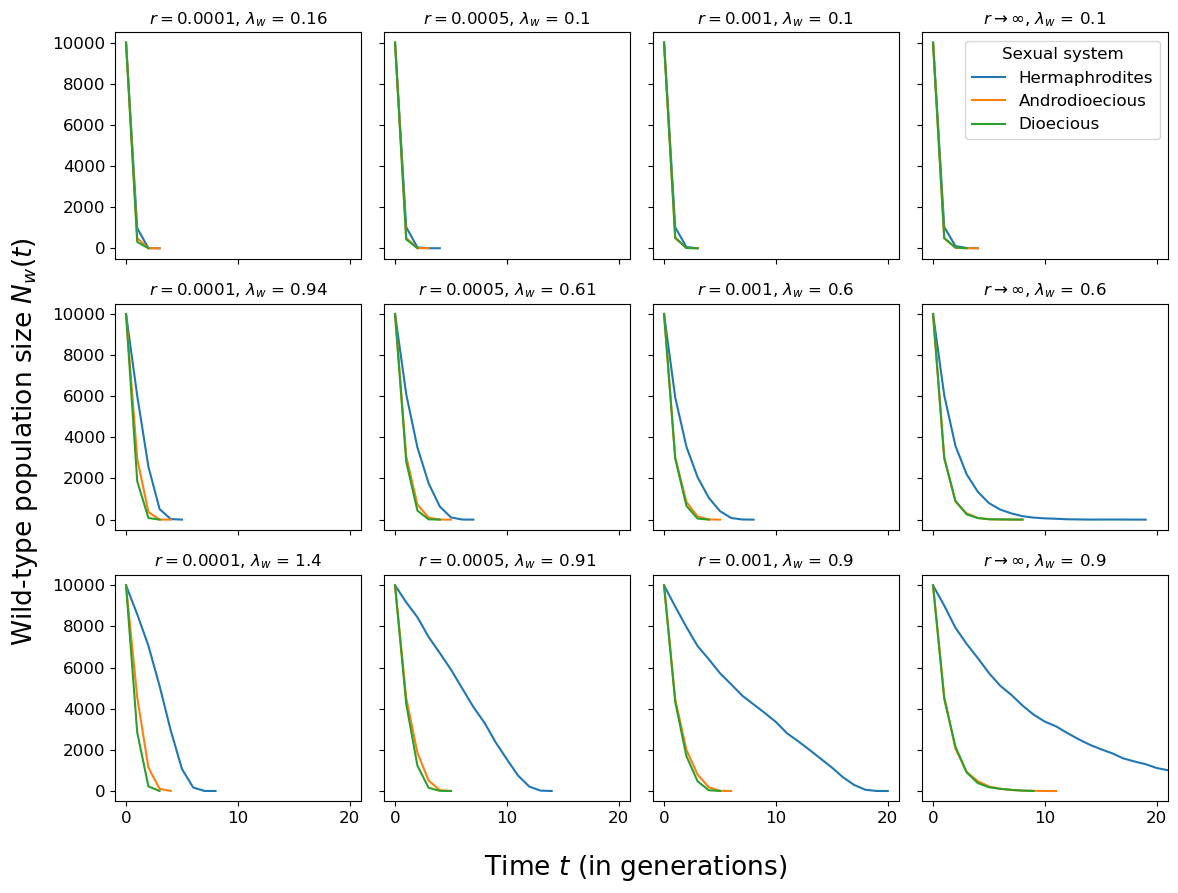

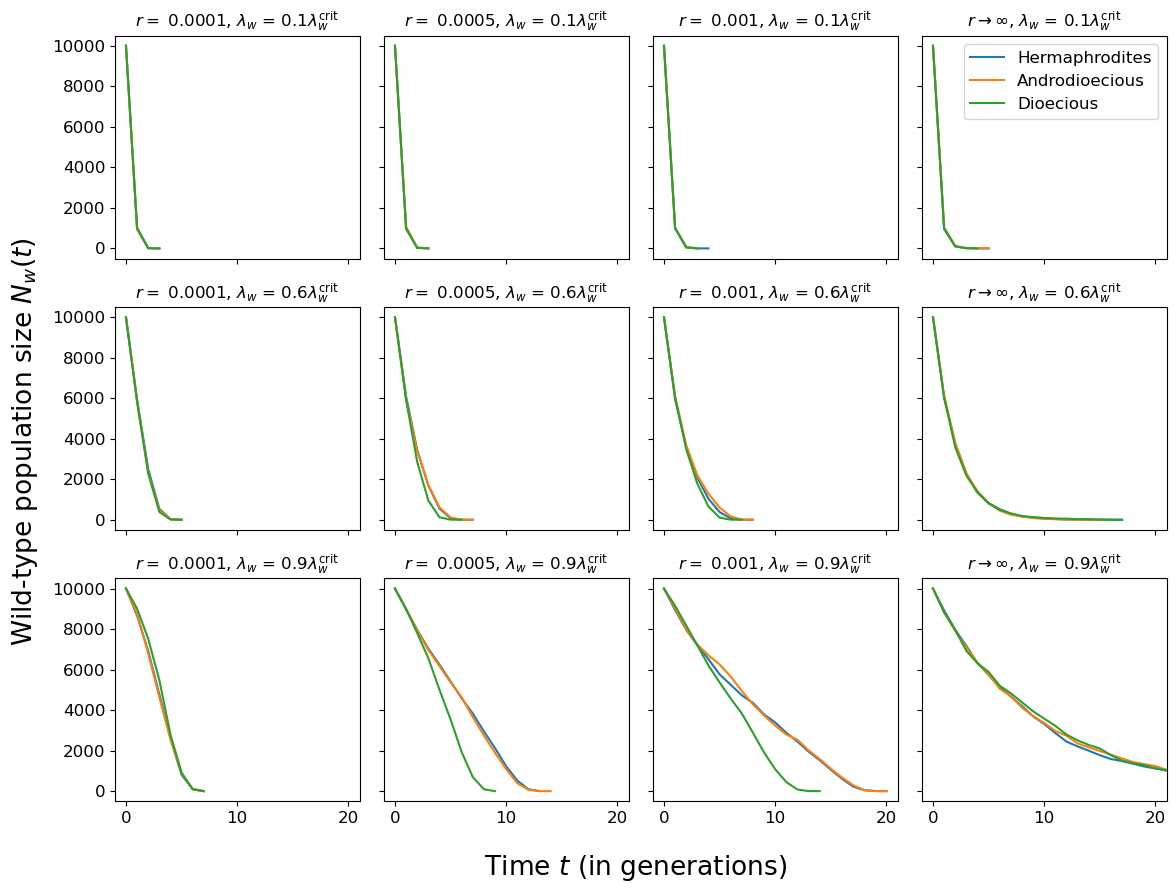

In [67]:
r_rng = [0.0001,0.0005,0.001,'AM']
lw_norm_rng = [0.1,0.6,0.9]
LCwriter = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
LCDF = pd.read_excel(LCwriter, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)

#lw_un_rng = [LCDF['Unisexual'][r] for r in r_rng]
#lw_bi_rng = [LCDF['Bisexual'][r] for r in r_rng]
#lw_an_rng = [LCDF['Androdioecious'][r] for r in r_rng]

fig, ax = plt.subplots(3,4,sharex=True,sharey=True,figsize=(12,9))

for r_ind, r in enumerate(r_rng):
    for lw_norm_ind, lw_norm in enumerate(lw_norm_rng): 
        
        if r != 'AM':
            lw_bi = lw_norm*LCDF['Hermaphroditic'][r]
            lw_an = lw_norm*LCDF['Androdioecious'][r]
            lw_un = lw_norm*LCDF['Dioecious'][r]
        else: 
            lw_bi = 1
            lw_an = 2
            lw_un = 2
            
            
        lw = lw_norm*LCDF['Hermaphroditic'][r] if r != 'AM' else lw_norm
        Ext, Un_timeseries, T = Unisexual(r,lw,lw,N0=10**4,mu=10**(-4),sgv=0,sr=0.5, timeseries=True)
        Ext, Bi_timeseries, T = Bisexual(r,lw,lw,N0=10**4,mu=10**(-4),sgv=0, ID_self=0, ps=0, timeseries=True)
        Ext, An_timeseries, T = Androdioecious(r,lw,lw,N0=10**4,mu=10**(-4),sgv=0,sr=0.5,ps=0,ID_self=0,timeseries=True) 
        

        Bi_pop = np.array(Bi_timeseries).sum(axis=1)
        Un_pop = np.array(Un_timeseries).sum(axis=1)
        An_pop = np.array(An_timeseries).sum(axis=1)
        ax[lw_norm_ind][r_ind].plot(range(len(Bi_pop)),Bi_pop,label='Hermaphrodites')
        ax[lw_norm_ind][r_ind].plot(range(len(An_pop)),An_pop,label='Androdioecious')
        ax[lw_norm_ind][r_ind].plot(range(len(Un_pop)),Un_pop,label='Dioecious')
        if r != 'AM':
            ax[lw_norm_ind][r_ind].set_title('$r = $'+str(r)+', $\lambda_w$ = ' + str(round(lw,2)),fontsize=12)
        else:
            ax[lw_norm_ind][r_ind].set_title('$r\\rightarrow \\infty$, $\lambda_w$ = ' + str(round(lw,2)),fontsize=12)
        #ax[lw_norm_ind][r_ind].plot(range(20),[10**4*lw_norm**gen for gen in range(20)],linestyle='--',color='grey')
fig.supylabel('Wild-type population size $N_w(t)$',fontsize=19)
fig.supxlabel('            Time $t$ (in generations)',fontsize=19)
ax[0][-1].legend(title = 'Sexual system')
#handles, labels = ax[0][1].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper right',bbox_to_anchor=(1.25,0.6),title = 'Sexual system')
plt.tight_layout()
plt.xlim(-1,21)

plt.savefig('DecayRate.jpg',format="jpg", dpi=300,bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(3,4,sharex=True,sharey=True,figsize=(12,9))
for r_ind, r in enumerate(r_rng):
    for lw_norm_ind, lw_norm in enumerate(lw_norm_rng): 
        if r != 'AM':
            lw_bi = lw_norm*LCDF['Hermaphroditic'][r]
            lw_an = lw_norm*LCDF['Androdioecious'][r]
            lw_un = lw_norm*LCDF['Dioecious'][r]
        else: 
            lw_bi = 1*lw_norm
            lw_an = 2*lw_norm
            lw_un = 2*lw_norm
        
        Ext, Un_timeseries, T = Unisexual(r,lw_un,lw_un,N0=10**4,mu=10**(-4),sgv=0,sr=0.5, timeseries=True)
        Ext, Bi_timeseries, T = Bisexual(r,lw_bi,lw_bi,N0=10**4,mu=10**(-4),sgv=0, ID_self=0, ps=0, timeseries=True)
        Ext, An_timeseries, T = Androdioecious(r,lw_an,lw_an,N0=10**4,mu=10**(-4),sgv=0,sr=0.5,ps=0,ID_self=0,timeseries=True) 
        Bi_pop = np.array(Bi_timeseries).sum(axis=1)
        Un_pop = np.array(Un_timeseries).sum(axis=1)
        An_pop = np.array(An_timeseries).sum(axis=1)
        ax[lw_norm_ind][r_ind].plot(range(len(Bi_pop)),Bi_pop,label='Hermaphrodites')
        ax[lw_norm_ind][r_ind].plot(range(len(An_pop)),An_pop,label='Androdioecious')
        ax[lw_norm_ind][r_ind].plot(range(len(Un_pop)),Un_pop,label='Dioecious')
        if r != 'AM':
            ax[lw_norm_ind][r_ind].set_title('$r =$ '+str(r)+', $\lambda_w$ = ' + str(round(lw_norm,2)) + '$\lambda_w^{\\text{crit}}$',fontsize=12)
        else: 
            ax[lw_norm_ind][r_ind].set_title('$r\\rightarrow \\infty$, $\lambda_w$ = ' + str(round(lw_norm,2)) + '$\lambda_w^{\\text{crit}}$',fontsize=12)
        
        #ax[lw_norm_ind][r_ind].plot(range(100),[10**4*lw_norm**gen for gen in range(100)],linestyle='--',color='grey')
        
fig.supylabel('Wild-type population size $N_w(t)$',fontsize=19)
fig.supxlabel('            Time $t$ (in generations)',fontsize=19)
ax[0][-1].legend(title='Sexual system')
plt.xlim(-1,21)
ax[0][-1].legend()
#handles, labels = ax[0][1].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper right',bbox_to_anchor=(1.25,0.6),title = 'Mating System')
plt.tight_layout()
plt.savefig('DecayRate_Normalized.jpg',format="jpg", dpi=300,bbox_inches='tight')

## Fig S4 - Critical mutant fecundity with scaled wild-type fecundity

This requires the same files as Figure 2. See Figure 2 instructions for generating the files

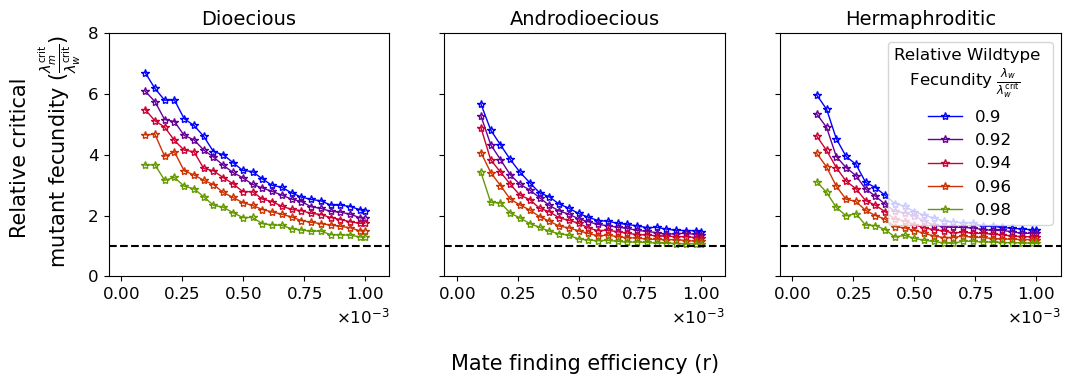

In [68]:
writer = pd.ExcelFile(pth+'LamdaCriticalMutant_CM_MRp-4_PS10000.xlsx')
LCwriter = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
LCDF = pd.read_excel(LCwriter, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)
#lw_crit = [LCDF['Unisexual'][r] for r in r_rng]

fig, ax_pt = plt.subplots(1, 3, sharex=True, sharey=True, figsize = (11,4))

DF = pd.read_excel(writer, sheet_name = 'Dioecious',index_col = 0) 


for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])/np.array([ LCDF['Dioecious'][r] for r in xvals ])
    ax_pt[0].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
    
ax_pt[0].axhline(y=1, color = 'black', linestyle = '--')
ax_pt[0].set_title('Dioecious',fontsize=14)

DF = pd.read_excel(writer, sheet_name = 'Hermaphroditic',index_col = 0) 
for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])/np.array([ LCDF['Hermaphroditic'][r] for r in xvals ])
    ax_pt[2].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
ax_pt[2].axhline(y=1, color = 'black', linestyle = '--')
ax_pt[2].set_title('Hermaphroditic',fontsize=14)

DF = pd.read_excel(writer, sheet_name = 'Androdioecious',index_col = 0) 
for i_ind,i in enumerate(DF.columns[:-1]): 
    xvals = DF.index
    yvals = np.array(DF[i])/np.array([ LCDF['Androdioecious'][r] for r in xvals ])
    ax_pt[1].plot(xvals,yvals, color=cmap(i_ind/len(DF.columns[:-1])), label=str(round(i,5)), mfc = 'none', lw = 1, marker = "*")
    
ax_pt[1].axhline(y=1, color = 'black', linestyle = '--')


lg=ax_pt[2].legend(title = 'Relative Wildtype \n   Fecundity $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}}$')
lg._legend_box.align = "center"
ax_pt[1].set_title('Androdioecious',fontsize=14)

handles, labels = ax_pt[0].get_legend_handles_labels()
ax_pt[0].set_ylabel('Relative critical \n mutant fecundity ($\\frac{\lambda_m^{\\text{crit}}}{ \lambda_w^{\\text{crit}} }$)', fontsize=15)
ax_pt[1].set_xlabel('\n\nMate finding efficiency (r)', fontsize=15)
ax_pt[0].xaxis.major.formatter._useMathText = True
ax_pt[1].xaxis.major.formatter._useMathText = True
ax_pt[2].xaxis.major.formatter._useMathText = True
plt.xlim(-0.05*10**(-3),1.1*10**(-3))
plt.ylim(0,8)
plt.tight_layout()
plt.ticklabel_format(style='sci', axis='x', scilimits= (0,0))

plt.savefig('Supplemental_LambdaCriticalMt.jpg',format="jpg", dpi=300)

## Fig S5 - Critical wildtype fecundity accounting for demographic stochasticity 

Same as Figure 2

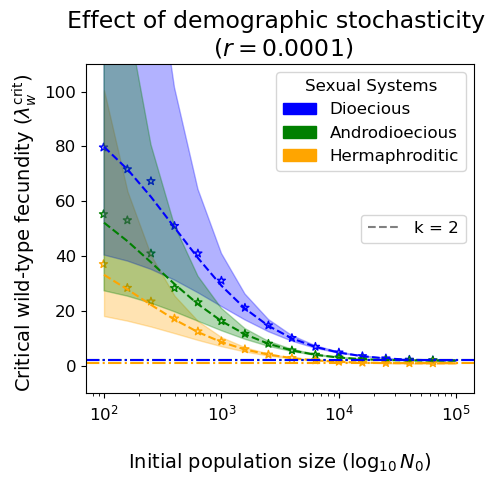

In [69]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

def corrected_crit(r,N0,alpha_f, alpha_m,k=2):
    u = 1-np.exp(-r*alpha_m*N0)
    ak = k**2*(1-u)/(alpha_f*u)
    return 1/(alpha_f*u)*( 1 + ( k**2/2 + ak )/(N0-ak) )*(1 - np.sqrt( 1 - (N0**2 - ak*N0)/(N0 + k**2/2)**2 ))
    #return (N0+2)/(alpha_f*u*N0 - 4*(1-u)) * ( 1 - np.sqrt( 1 - (N0**2 - 4*N0*(1-u)/(alpha_f*u))/(N0+2)**2 ) )


writer = pd.ExcelFile(pth+'LamdaCritical_CM_MRp-4.xlsx')
DF = pd.read_excel(writer, sheet_name = 'Lamda_Cutoff_r' ,index_col=0)
DF = DF[DF.index < 0.00102]
#DF = DF[DF.index >= 0.00006]
colors = ['blue','green','orange']
color_ind =0
fig, ax = plt.subplots(1,1,sharex=False, sharey=False,figsize=(5,5))

DF = pd.read_excel(writer, sheet_name = 'Lamda_Cutoff_N0' ,index_col=0)
DF = DF.loc[DF.index>90]
color_ind =0
modelname = ['Dioecious','Androdioecious','Hermaphroditic']
for model_ind, model in enumerate(modelname):
    ax.scatter(list(DF.index),list(DF[model]),marker = '*',c='none',edgecolors=colors[color_ind], label = modelname[model_ind]+' - Simulations')
    color_ind += 1
"""
for model_ind, model in enumerate(modelname):
    ax.scatter(list(DF.index),list(DF[model]),marker = '*',c='none',edgecolors=colors[color_ind], label = modelname[model_ind]+' - Simulations')
    color_ind += 1
    if model == 'Dioecious':
        analy = [ 2/(1-np.exp(1)**(-0.0001*N0*0.5) ) for N0 in list(DF.index)]
        ax.plot(list(DF.index),analy, color = 'blue', label = modelname[model_ind] + ' - Theory')
    elif model == 'Androdioecious' :
        analy = [ 2/(1-np.exp(1)**(-0.0001*(N0-1) ) ) for N0 in list(DF.index)]
        ax.plot(list(DF.index),analy, color = 'green', label = modelname[model_ind] + ' - Theory')
    elif model == 'Hermaphroditic' :
        analy = [ 1/(1-np.exp(1)**(-0.0001*(N0-1) ) ) for N0 in list(DF.index)]
        ax.plot(list(DF.index),analy, color = 'orange', label = modelname[model_ind] + ' - Theory')
"""

r = 10**(-4)
k=2
klow = 0 
kup = 4.41
xrange = [10**x for x in np.arange(2,5.1,0.2)]
ycorrected = [ corrected_crit(r,N0,1,1,k) for N0 in xrange ]
ylower = [ corrected_crit(r,N0,1,1,klow) for N0 in xrange ]
yupper = [ corrected_crit(r,N0,1,1,kup) for N0 in xrange ]
ax.fill_between(xrange, ylower, yupper, alpha=0.3, color='orange')
ax.plot(xrange, ycorrected, linestyle = '--', color = 'orange')

ycorrected = [ corrected_crit(r,N0,0.5,0.5,k) for N0 in xrange ]
ylower = [ corrected_crit(r,N0,0.5,0.5,klow) for N0 in xrange ]
yupper = [ corrected_crit(r,N0,0.5,0.5,kup) for N0 in xrange ]
ax.fill_between(xrange, ylower, yupper, alpha=0.3, color='blue')
ax.plot(xrange, ycorrected, linestyle = '--', color = 'blue')

ycorrected = [ corrected_crit(r,N0,0.5,1,k) for N0 in xrange ]
ylower = [ corrected_crit(r,N0,0.5,1,klow) for N0 in xrange ]
yupper = [ corrected_crit(r,N0,0.5,1,kup) for N0 in xrange ]
ax.fill_between(xrange, ylower, yupper, alpha=0.3, color='green')
ax.plot(xrange, ycorrected, linestyle = '--', color = 'green')


#solid_line = mlines.Line2D([], [], color='grey', linestyle='-', label='Theory ')
dashed_line = mlines.Line2D([], [], color='grey', linestyle='--', label='k = 2')
#empty_star = mlines.Line2D([], [], color='grey', marker='*', linestyle='None', markersize=10, markerfacecolor='none', markeredgecolor='grey', label='Simulations')

legend1 = ax.legend(handles=[dashed_line],  title="", loc='center right')


# --- Legend for colors on ax[1] ---
blue_patch = mpatches.Patch(color='blue', label='Dioecious')
red_patch = mpatches.Patch(color='green', label='Androdioecious')
orange_patch = mpatches.Patch(color='orange', label='Hermaphroditic')

legend2 = ax.legend(handles=[blue_patch, red_patch, orange_patch], title="Sexual Systems", loc='upper right')

# Add first legend manually (otherwise second legend overwrites it)
ax.add_artist(legend1)

        
%matplotlib inline
ax.axhline(y=1,linestyle = '-.',color='orange')
ax.axhline(y=2,linestyle = '-.',color='green')
ax.set_xscale('log')
ax.axhline(y=2,linestyle = '-.',color='blue')
ax.set_xlabel('\nInitial population size ($\log_{10}N_0$)')#,fontsize = 15)
ax.set_title('Effect of demographic stochasticity \n ($r = 0.0001$)')#, fontsize = 18)
ax.set_xscale('log')
ax.set_ylim((-10,110))
#ax[1].legend(fontsize=10)
fig.align_xlabels()
ax.set_ylabel('Critical wild-type fecundity ($\lambda_w^{\\text{crit}}$)  ')#, fontsize = 15)
plt.tight_layout()
plt.savefig("LambdaCritical_supp.jpg",format="jpg", dpi=300)

plt.show()

## Fig S6 - Establishment probability as a function of wild-type population size

This requires the excel file `RescueProb_WtPopSize.xlsx` generated using the python file `SupplementalFigure_WtPopSize.py` (Corresponding bash script for cluster `SupplementalFigure_WtPopSize.sh`)

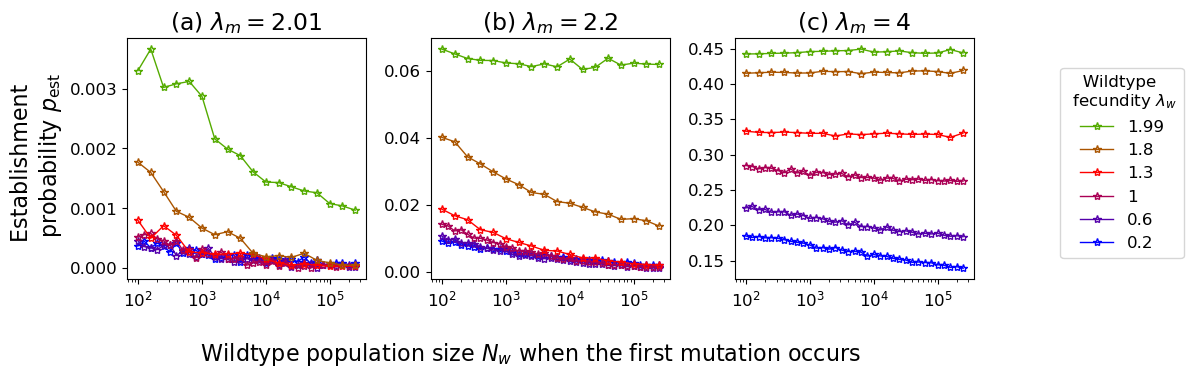

In [70]:
import math 

writer = pd.ExcelFile(pth+'RescueProb_WtPopSize.xlsx')

mu_rng = 10**np.array([-np.inf])
p_rng  = ['single']
prefix = ['(a)', '(b)','(c)', '(d)','(e)','(f)','(g)']

lw_rng = [0.2,0.6,1,1.3,1.8,1.99]
lm_rng = [2.01,2.2,4]


fig, ax = plt.subplots(1,len(lm_rng),figsize = (10,3.8), sharey = 'col')

for lm_ind, lm in enumerate(lm_rng):
    for lw_ind, lw in enumerate(lw_rng): 
        DF = pd.read_excel(writer,sheet_name = 'Un_lw'+str(lw)+'_lm'+str(lm), index_col = 0 )
        DF = DF.transpose()
        #fig, ax = plt.subplots(1,1,figsize = (4.6,4.5),sharex=True,sharey=True)
        #fig = plt.figure(figsize= (5.6,4.8))
        for mu_ind, mu in enumerate(mu_rng): 
            #print(r)
            ax[lm_ind].plot(np.array(DF.index)-1, 1-np.array(DF[mu]), label = str(lw), marker = '*', lw=1,mfc='none', color = cmap(lw_ind/len(lw_rng)))
        ax[lm_ind].set_xscale('log')
        ax[lm_ind].set_title(prefix[lm_ind] + r' $\lambda_m=$'+str(lm))
        #plt.xaxis.major.formatter._useMathText = True
        #plt.ylim((-0.01,0.2))
        
handles, labels = ax[0].get_legend_handles_labels()
leg = fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1.2,0.55),title = '   Wildtype \n fecundity $\lambda_w$')      
ax[0].set_ylabel('Establishment \n probability $p_{\\text{est}}$',fontsize = 16)
fig.supxlabel('           Wildtype population size $N_w$ when the first mutation occurs', fontsize = 16)
#fig.supylabel('Rescue Probability', fontsize = 16)

#ax[0].set_xlabel('Initial population size $N_0$', fontsize = 16)
plt.tight_layout()
#ax[2].set_ylim(-0.01,0.5)
plt.savefig('Supplemental_RescueProb_PopSize.jpg',format="jpg", dpi=300,bbox_inches='tight')
plt.show()

## Fig S7 - SGV vs DNM for $N_m(0) = 10$

This requires the excel file `RescueProb_SGVvsDNM_10_MR-3.xlsx` that can be generated in a similar fashion as Figure 4 by changing the parameter of frequency of mutants in SGV from $10^{-4}$ to $10^{-3}$ for the rescue by SGV case and the mutation rate from $10^{-4}$ to $10^{-3}$. 

/tmp/ipykernel_234052/1462445634.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


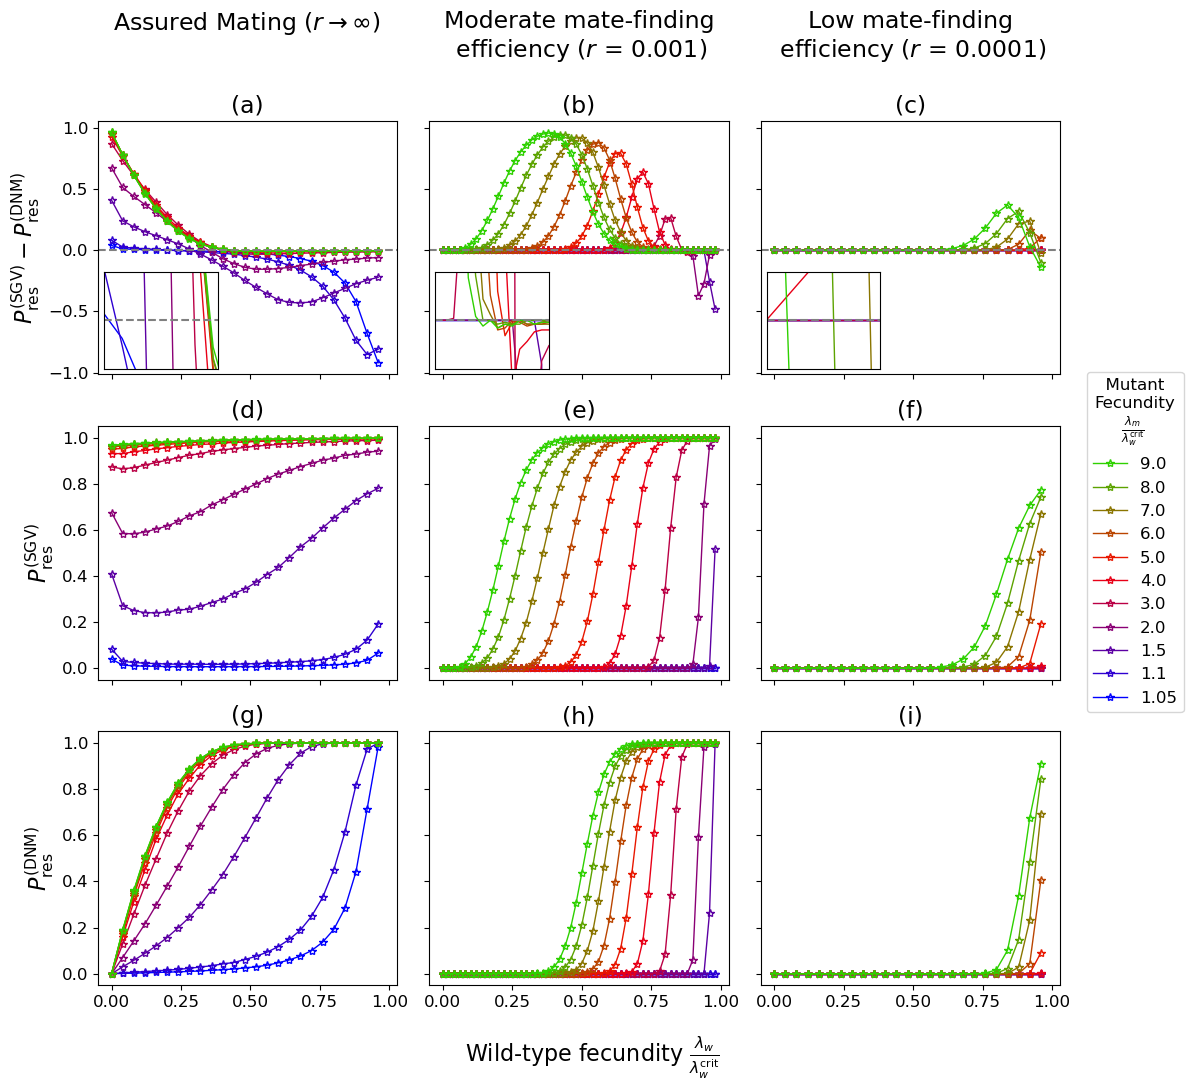

In [71]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
writer = pd.ExcelFile(pth+'RescueProb_SGVvsDNM_10_MR-3.xlsx')

r_rng = ['AM',0.001,0.0001]
r_rng_txt = ['0.001','0.0001','AM']

fig, ax_pt = plt.subplots(3, 3, sharex=True, sharey='row', figsize = (12,11))
ty = ['SGV','DNM']
modelname = ['SGV','denovo mutation']

for j in range(3) :     
    r = r_rng[j]
    DF_SGV = pd.read_excel(writer,sheet_name = str(ty[0])+'_'+str(r_rng[j]), index_col = 0 )
    DF_DNM = pd.read_excel(writer,sheet_name = str(ty[1])+'_'+str(r_rng[j]), index_col = 0 )        
    for lw_ind, lw in enumerate(DF_DNM.columns):
        
        x_list = [x for x in DF_DNM.index if x < 1]
        y_list = np.array(DF_DNM[lw])-np.array(DF_SGV[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[0][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
        x_list = [x for x in DF_DNM.index if x < 1]
        y_list = 1-np.array(DF_SGV[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[1][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
        y_list = 1-np.array(DF_DNM[lw])
        y_list = y_list[0:len(x_list)]
        ax_pt[2][j].plot(np.array(x_list),y_list, marker = '*', color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        
    ax_pt[0][j].axhline(y=0,linestyle = '--',color='grey')
    
    axin = inset_axes(ax_pt[0][j], width="38%", height="38%", loc='lower center', bbox_to_anchor=(-0.29,-0.01,1,1), bbox_transform=ax_pt[0][j].transAxes)
    for lw_ind, lw in enumerate(DF_DNM.columns):
        x_list = [x for x in DF_DNM.index if x < 1]
        y_list = np.array(DF_DNM[lw])-np.array(DF_SGV[lw])
        y_list = y_list[0:len(x_list)]
        axin.plot(np.array(x_list),y_list, color = cmap(lw_ind/len(DF_DNM.columns)), mfc = 'none', lw=1, label = str(lw))
        axin.set_xticks([])
        axin.set_yticks([])
        if j == 0:
            axin.set_xlim(0.2,0.45)
            axin.set_ylim(-0.0025,0.0025)
        elif j == 1:
            axin.set_xlim(0.65,0.96)
            axin.set_ylim(-0.00025,0.00025)
        elif j == 2:
            axin.set_xlim(0.92,0.96)
            axin.set_ylim(-0.0025,0.0025)
    axin.axhline(y=0,linestyle = '--',color='grey')
        

ax_pt[0][2].set_title('Low mate-finding\n efficiency ($r$ = 0.0001) \n\n(c)')
ax_pt[0][1].set_title('Moderate mate-finding\n efficiency ($r$ = 0.001) \n\n(b)')
ax_pt[0][0].set_title('Assured Mating ($r \\rightarrow \\infty$) \n \n\n(a)')

ax_pt[1][2].set_title('(f)')
ax_pt[1][1].set_title('(e)')
ax_pt[1][0].set_title('(d)')

ax_pt[2][2].set_title('(i)')
ax_pt[2][1].set_title('(h)')
ax_pt[2][0].set_title('(g)')


handles, labels = ax_pt[0][0].get_legend_handles_labels()
handles2, labels2 = ax_pt[0][2].get_legend_handles_labels()
fig.legend(handles2[::-1], labels2[::-1], loc='right',bbox_to_anchor=(1,0.5),title = '  Mutant \nFecundity\n     $\\frac{\lambda_m}{\lambda_w^{\\text{crit}}}$')
fig.supxlabel('Wild-type fecundity $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}}$', fontsize = 16)
ax_pt[0][0].set_ylabel('$P_{\\text{res}}^{(\\text{SGV})}-P_{\\text{res}}^{(\\text{DNM})}$', fontsize = 16)
        
ax_pt[1][0].set_ylabel('$P_{\\text{res}}^{(\\text{SGV})}$', fontsize = 16)
ax_pt[2][0].set_ylabel('$P_{\\text{res}}^{(\\text{DNM})}$', fontsize = 16)

ax_pt[1][0].set_ylim(-0.05,1.05)
ax_pt[2][0].set_ylim(-0.05,1.05)

plt.tight_layout()
plt.subplots_adjust(right=0.89)
plt.savefig('Supplemental_RescueProb_SGVvsDNM.jpg',format="jpg", dpi=300)

## Fig S8 - Fecundity vs Mate-finding for different trade-off functions

The files for this can be generated similar to Figure 5 by changing the python file as follows
1. Change typ = 2 (instead of 1) to generate `RescueProb_FindingvsFecundity_type2.xlsx`
2. Change typ = 2 (instead of 1) and change Nchoice = $10^4$ to generate `RescueProb_FindingvsFecundity_type3.xlsx`
3. Change the name of the excel file appropriately

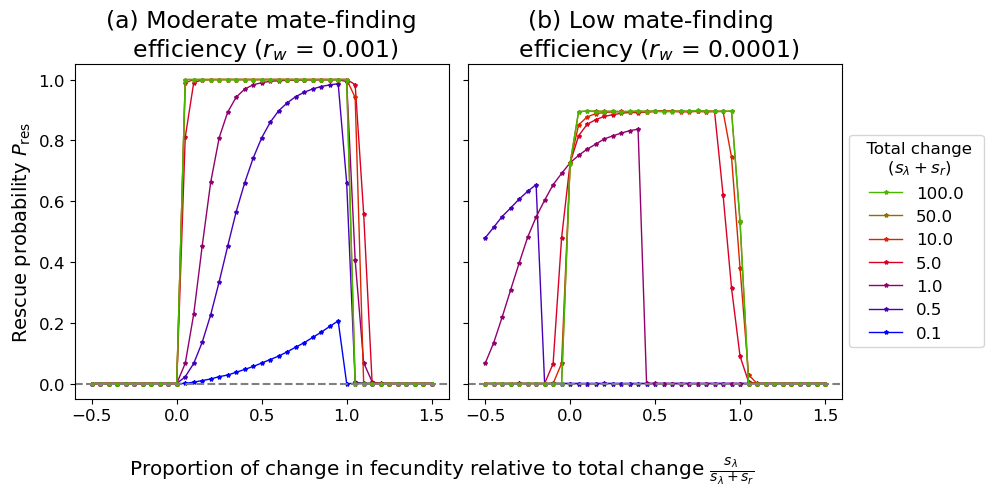

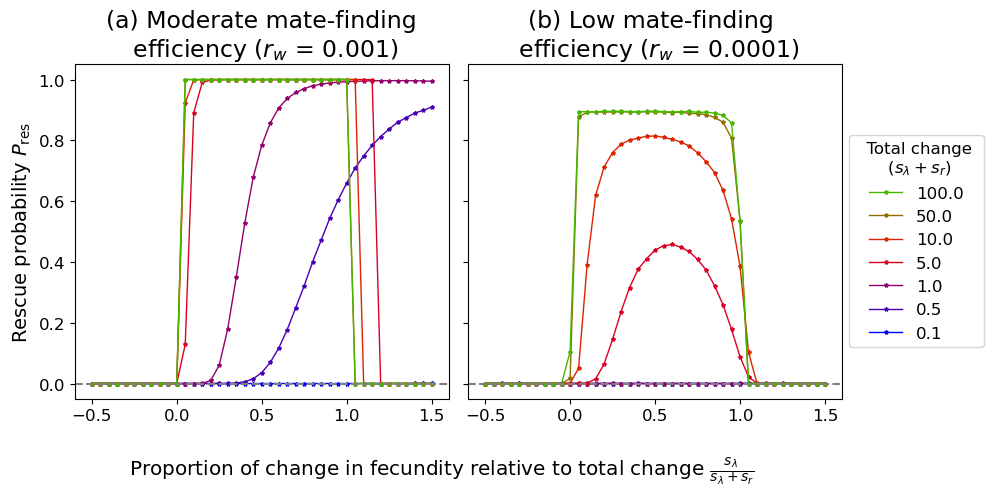

In [72]:
for typ in ["_type2", "_type3"]:
    writer = pd.ExcelFile(pth+'RescueProb_FindingvsFecundity' + typ + '.xlsx')

    r_rng = [0.001, 0.0001]
    r_rng_txt = ['0.001', '0.0001']

    %matplotlib inline
    fig, ax_pt = plt.subplots(1, 2, sharey=True, sharex=True, figsize = (10,5))

    for i in range(len(r_rng)) :
        r = r_rng[i]
        DF = pd.read_excel(writer,sheet_name = str(r_rng[i]), index_col = 0 )
        DF = DF.transpose()
        for lw_ind, lw in enumerate(DF.columns):
            ax_pt[i].plot(DF.index,1-np.array(DF[lw]),color = cmap(lw_ind/len(DF.columns)),mfc ='none',lw=1, marker = '*',label = str(lw/100),ms=3)
        ax_pt[i].tick_params(axis='both')#, labelsize=13)
        ax_pt[i].axhline(y=0, linestyle = '--', color = 'grey')

    ax_pt[1].set_title("(b) Low mate-finding \n efficiency ($r_w$ = 0.0001)")#, fontsize = 13)
    ax_pt[0].set_title("(a) Moderate mate-finding\n efficiency ($r_w$ = 0.001)")#, fontsize = 13)

    ax_pt[0].set_ylabel('Rescue probability $P_{\\text{res}}$')#, fontsize = 19)
    #fig.supxlabel('Proportion of increase allocated to Fecundity $\\frac{\lambda_w^{-1}\Delta \lambda}{\lambda_w^{-1}\Delta \lambda + r_w^{-1}\Delta r}$', fontsize = 19,x=0.45)
    fig.supxlabel('Proportion of change in fecundity relative to total change $\\frac{s_\lambda}{s_\lambda+s_r}$',x=0.45)
    plt.tight_layout()
    handles, labels = ax_pt[0].get_legend_handles_labels()
    fig.legend(handles[::-1], np.array(labels[::-1]), loc='right',bbox_to_anchor=(1,0.5),title = '  Total change \n      $(s_\lambda+s_r)$ ')      
    plt.subplots_adjust(right=0.85)
    plt.savefig('RescueProb_FindingvsFecundity'+ typ + '.jpg',format="jpg", dpi=300)
    plt.show()

## Fig S9 - Rescue probability as a function of sex ratio for low mutant fecundity and rapid wild-type decay

This can be generated using the code for Figure 6 with parameters given in the supplementary section of te 

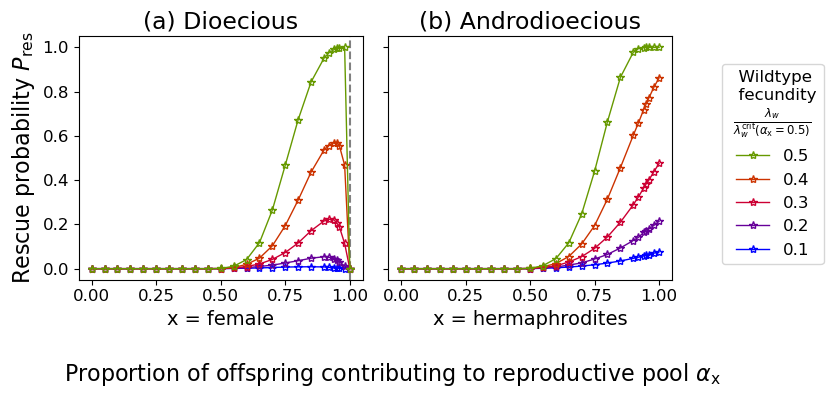

In [73]:
writer = pd.ExcelFile(pth+'RescueProb_SexRatio_finer.xlsx')
#writerAM = pd.ExcelFile('RescueProb_SexRatio_AssuredMating_30.xlsx')

model = 'Dioecious'
fig, ax = plt.subplots(1,2,figsize = (8,4),sharex=True,sharey=True)

N0 = 10**4
r = 'AM'
func = lambda alpha : 1 - (1 + alpha*r*N0)*np.exp(-r*(1-alpha)*N0)
alpha_solution = fsolve(func, 0.8) if r != 'AM' else 1 - 10**-4
ax[0].axvline(x=alpha_solution, linestyle = '--', color = 'grey')

DF = pd.read_excel(writer,sheet_name = 'Dioecious_AM', index_col = 0 )
DF = DF.transpose()

for s_ind,s in enumerate(DF.columns): 
    ax[0].plot(list(DF.index),1-np.array(DF[s]), color=cmap(s_ind/len(DF.columns)),mfc ='none',lw=1, label = str(round(s,2)), marker ='*' )
    
DF = pd.read_excel(writer,sheet_name = 'Androdioecious_AM', index_col = 0 )
DF = DF.transpose()

for s_ind, s in enumerate(DF.columns): 
    ax[1].plot(list(DF.index),1-np.array(DF[s]), color=cmap(s_ind/len(DF.columns)),mfc ='none',lw=1, label = str(round(s,2)), marker ='*' )
    
ax[0].set_title('(a) Dioecious')
ax[1].set_title('(b) Androdioecious')
    
ax[0].set_ylabel('Rescue probability $P_{\\text{res}}$',fontsize = 16)
fig.supxlabel('Proportion of offspring contributing to reproductive pool $\\alpha_{\\text{x}}$', fontsize = 16)
ax[0].set_xlabel('x = female', fontsize =14)
ax[1].set_xlabel('x = hermaphrodites', fontsize =14)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], loc='right',bbox_to_anchor=(1.05,0.57),title = '  Wildtype\n  fecundity\n $\\frac{\lambda_w}{\lambda_w^{\\text{crit}}(\\alpha_\\text{x}=0.5)}$')      
ax = ax[0]
plt.tight_layout()
plt.subplots_adjust(right=0.85)

plt.savefig('Supplemental_RescueProb_SexRatio.jpg',format='jpg',dpi=300,bbox_inches='tight')


## Extra figure

This figure is not in the manuscript or the supplementary but was helpful in understanding Fig S8 and supp section S2.6 

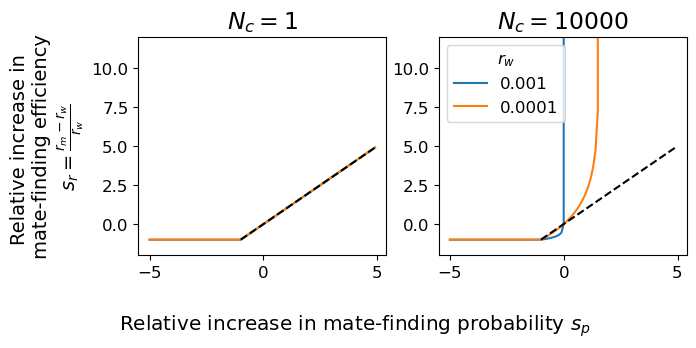

In [74]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sr_sp(rw_range, alpha, Nc, sp_range, ax):
    """
    Plot s_r = (r_m - r_w)/r_w as a function of s_p.

    Parameters:
    - r_w: float (fixed)
    - alpha: float (fixed)
    - M: float or int (fixed)
    - N_c: float (fixed)
    - s_p_range: array-like (values of s_p)
    """
    
    for rw in rw_range:
        sr_values = []
        for sp in sp_range:
            # Inner expression
            inner = 1 - (1 + sp) * (1 - np.exp(-rw * alpha * Nc))

            # Apply inner max
            inner = max(inner, 0)

            if inner > 0:
                rm = (1 / (alpha * Nc)) * max(-np.log(inner), 0)
            else:
                rm = 2

            # Compute s_r
            sr = (rm - rw) / rw
            sr_values.append(sr)
            #print(sp, sr)

        ax.plot(sp_range, sr_values, label = str(rw))
    #plt.xlabel(r"$s_p$")
    #plt.ylabel(r"$s_r = \frac{r_m - r_w}{r_w}$")
    #plt.title(r"Selection response $s_r$ vs preference $s_p$")
fig, ax = plt.subplots(1,2, figsize = (7,3.5))
alpha = 0.5
rw = [10**(-3),10**(-4)]
Nc_range = [1,10**4]
sp_range = np.arange(-5,5,0.1)
for i,Nc in enumerate(Nc_range) :
    plot_sr_sp(rw, alpha, Nc, sp_range, ax[i])
    ax[i].plot([-1,sp_range[-1]],[-1,sp_range[-1]],linestyle = '--',color='black')
    ax[i].set_ylim([-2,12])
    ax[i].set_title(r"$N_c=$"+str(Nc))
ax[1].legend(title=r"$r_w$")
fig.supxlabel(r"Relative increase in mate-finding probability $s_p$")
ax[0].set_ylabel("Relative increase in \n mate-finding efficiency \n" + r"$s_r = \frac{r_m - r_w}{r_w}$")
plt.tight_layout()
plt.show()